# Making a small training loop tell the truth about itself

(Built as ERA V5 Session 10 assignment.)

A nanoGPT-style character model on Tiny Shakespeare, trained for real, then opened up.
Six questions, each answered with an experiment whose output is below:

1. What shape is every tensor in one step, and what does each dimension mean?
2. Does `backward()` agree with physically nudging one weight?
3. What does average-of-averages accumulation do when micro-batches hold different numbers of tokens?
4. Is there a step where the grad norm moves before the loss does?
5. What MFU does this loop actually get, and where does the distance to 40% go?
6. What are the bits of 0.1 in fp32, bf16 and fp8 E4M3, and which would I train in?

Every claim that can be a check is a `check(...)` call; a failed check stops the notebook.
Machine-readable evidence is written to `artifacts/`, figures to `figures/`.

In [1]:
import os, sys, json, math, time, copy, hashlib, platform, subprocess, re
from contextlib import nullcontext
from fractions import Fraction

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
from torch.nn import functional as F

sys.path.insert(0, os.path.abspath("."))
from s10lab.model import GPT, GPTConfig, tracing
from s10lab.data import load_text, CharData, split_chunk, pad_speeches, length_buckets, make_windows, IGNORE
from s10lab.train import (autocast_ctx, token_loss_sum, accumulate, full_batch_backward, flat_grad,
                          compare_grads, train_loop, eval_loss, make_fast_step, time_steps, lr_at)
from s10lab import floats as fl

T_NOTEBOOK_START = time.time()
MODE = os.environ.get("S10_MODE", "full")   # "quick" = tiny CPU smoke test; the submitted run is "full"
QUICK = MODE == "quick"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs("artifacts", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# fp32 means fp32 here: TF32 is switched off globally and only switched on where a cell says so
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.set_float32_matmul_precision("highest")

pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.max_rows", 200)

CHECKS = []
def check(name, cond, detail=""):
    CHECKS.append({"check": name, "passed": bool(cond), "detail": str(detail)})
    assert cond, f"CHECK FAILED: {name} :: {detail}"
    print(f"  [ok] {name}" + (f"  ({detail})" if detail != "" else ""))

def save_json(name, obj):
    with open(os.path.join("artifacts", name), "w") as f:
        json.dump(obj, f, indent=2, default=str)

SECTION_SECONDS = {}
class section:
    def __init__(self, name): self.name = name
    def __enter__(self): self.t = time.time()
    def __exit__(self, *a): SECTION_SECONDS[self.name] = round(time.time() - self.t, 2)

print("mode:", MODE, "| device:", DEVICE)

mode: full | device: cuda


In [2]:
def gpu_info():
    if DEVICE != "cuda":
        return {"gpu": None}
    p = torch.cuda.get_device_properties(0)
    smi = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total,driver_version,clocks.max.sm",
                          "--format=csv,noheader"], capture_output=True, text=True).stdout.strip()
    return {"gpu": torch.cuda.get_device_name(0), "compute_capability": f"{p.major}.{p.minor}",
            "sm_count": p.multi_processor_count, "memory_GiB": round(p.total_memory / 2**30, 2),
            "nvidia_smi": smi, "cuda": torch.version.cuda, "cudnn": torch.backends.cudnn.version()}

ENV = {"python": platform.python_version(), "torch": torch.__version__, "numpy": np.__version__,
       "pandas": pd.__version__, "matplotlib": matplotlib.__version__, "platform": platform.platform(),
       **gpu_info()}
save_json("environment.json", ENV)
for k, v in ENV.items():
    print(f"{k:>20}: {v}")

              python: 3.11.12
               torch: 2.5.1+cu124
               numpy: 2.1.3
              pandas: 2.2.3
          matplotlib: 3.9.2
            platform: Linux-4.19.0-gvisor-x86_64-with-glibc2.36
                 gpu: NVIDIA A10G
  compute_capability: 8.6
            sm_count: 80
          memory_GiB: 22.06
          nvidia_smi: NVIDIA A10G, 23028 MiB, 610.57.04, 1710 MHz
                cuda: 12.4
               cudnn: 90100


## Configuration

All knobs live in this one cell and are written to `artifacts/config.json`.
The model is nanoGPT's `shakespeare_char` baby GPT (6 layers, 6 heads, 384 wide, 256 context) with dropout set to 0,
because the gradient check and the A/B accumulation runs need a forward pass that repeats exactly.

In [3]:
SEED = 1337
MODEL = dict(block_size=256, n_layer=6, n_head=6, n_embd=384, dropout=0.0, bias=False)
MAIN = dict(micro_batch=32, grad_accum=2, T=256, max_steps=1500, warmup_steps=100, lr=1e-3, min_lr=1e-4,
            betas=(0.9, 0.99), weight_decay=0.1, grad_clip=1.0, precision="bf16",
            eval_every=50, n_val_batches=20, val_batch=64, probe_batch=16)
GRADCHECK = dict(B=4, T=64, eps=1e-4, param="transformer.h.0.attn.c_attn.weight", n_random=8,
                 eps_sweep_fp64=[1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10, 1e-11],
                 eps_sweep_fp32=[1e-1, 3e-2, 1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 1e-5, 1e-6, 1e-7])
ACCUM = dict(micro_batch=8, n_micro=4, T=256, max_steps=600, warmup_steps=50, lr=1e-3, min_lr=1e-4,
             betas=(0.9, 0.99), weight_decay=0.1, grad_clip=1.0, precision="bf16", eval_every=25,
             cos_every=10, val_batch=64)
MFU = dict(n_warm=15, n_timed=60, batch_sweep=[8, 16, 32, 64, 128], profile_steps=5)
PREC = dict(max_steps=300)

if QUICK:  # tiny smoke-test sizes, never used for reported numbers
    MODEL.update(block_size=64, n_layer=2, n_head=2, n_embd=64)
    MAIN.update(micro_batch=4, T=64, max_steps=40, warmup_steps=5, eval_every=10, n_val_batches=2,
                val_batch=8, probe_batch=4)
    GRADCHECK.update(B=2, T=16)
    ACCUM.update(micro_batch=4, T=64, max_steps=20, warmup_steps=5, eval_every=10, cos_every=5, val_batch=8)
    PREC.update(max_steps=10)

tokens_per_step = MAIN["micro_batch"] * MAIN["grad_accum"] * MAIN["T"]
CONFIG = {"mode": MODE, "seed": SEED, "model": MODEL, "main_run": MAIN, "gradcheck": GRADCHECK,
          "accumulation": ACCUM, "mfu": MFU, "precision_compare": PREC,
          "main_tokens_per_optimizer_step": tokens_per_step,
          "optimizer": "AdamW (fused on CUDA), weight decay on >=2-D params only",
          "schedule": "linear warm-up then cosine to min_lr (nanoGPT get_lr)",
          "clipping": "clip_grad_norm_ at grad_clip, norm logged BEFORE clipping, every step"}
print(json.dumps(CONFIG, indent=1, default=str))

{
 "mode": "full",
 "seed": 1337,
 "model": {
  "block_size": 256,
  "n_layer": 6,
  "n_head": 6,
  "n_embd": 384,
  "dropout": 0.0,
  "bias": false
 },
 "main_run": {
  "micro_batch": 32,
  "grad_accum": 2,
  "T": 256,
  "max_steps": 1500,
  "warmup_steps": 100,
  "lr": 0.001,
  "min_lr": 0.0001,
  "betas": [
   0.9,
   0.99
  ],
  "weight_decay": 0.1,
  "grad_clip": 1.0,
  "precision": "bf16",
  "eval_every": 50,
  "n_val_batches": 20,
  "val_batch": 64,
  "probe_batch": 16
 },
 "gradcheck": {
  "B": 4,
  "T": 64,
  "eps": 0.0001,
  "param": "transformer.h.0.attn.c_attn.weight",
  "n_random": 8,
  "eps_sweep_fp64": [
   0.1,
   0.01,
   0.001,
   0.0001,
   1e-05,
   1e-06,
   1e-07,
   1e-08,
   1e-09,
   1e-10,
   1e-11
  ],
  "eps_sweep_fp32": [
   0.1,
   0.03,
   0.01,
   0.003,
   0.001,
   0.0003,
   0.0001,
   1e-05,
   1e-06,
   1e-07
  ]
 },
 "accumulation": {
  "micro_batch": 8,
  "n_micro": 4,
  "T": 256,
  "max_steps": 600,
  "warmup_steps": 50,
  "lr": 0.001,
  "min_lr"

## Data

Tiny Shakespeare, character level, exactly as nanoGPT's `data/shakespeare_char`: first 90% train, last 10% validation.
I also split the text on blank lines into *speeches*. Speeches vary from a few characters to hundreds,
which is what gives the accumulation experiment micro-batches with genuinely different numbers of valid targets.

In [4]:
with section("data"):
    text, sha256, path = load_text("data")
    D = CharData(text)
    print(f"file {path}  sha256 {sha256}")
    print(f"{len(text):,} characters | vocab V = {D.vocab_size} | train {len(D.ids['train']):,} | val {len(D.ids['val']):,}")
    print("vocab:", repr("".join(D.chars)))
    if not QUICK:
        check("vocabulary is the 65 Tiny Shakespeare characters", D.vocab_size == 65, D.vocab_size)
    check("train/val split is disjoint and complete", len(D.ids["train"]) + len(D.ids["val"]) == len(text))
    sp_lens = np.array([len(s) - 1 for s in D.speeches("train", 10**9)])
    print(f"train speeches: {len(sp_lens):,}; predictions per speech (untruncated): "
          f"min {sp_lens.min()}, median {int(np.median(sp_lens))}, p90 {int(np.percentile(sp_lens, 90))}, max {sp_lens.max()}")
CONFIG["data"] = {"name": "Tiny Shakespeare (karpathy/char-rnn)", "url": "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt",
                  "sha256": sha256, "chars": len(text), "tokenizer": "character level, sorted unique chars",
                  "vocab_size": D.vocab_size, "split": "first 90% train / last 10% val",
                  "train_tokens": len(D.ids["train"]), "val_tokens": len(D.ids["val"])}
save_json("config.json", CONFIG)

file data/input.txt  sha256 86c4e6aa9db7c042ec79f339dcb96d42b0075e16b8fc2e86bf0ca57e2dc565ed
1,115,394 characters | vocab V = 65 | train 1,003,854 | val 111,540
vocab: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
  [ok] vocabulary is the 65 Tiny Shakespeare characters  (65)
  [ok] train/val split is disjoint and complete
train speeches: 6,283; predictions per speech (untruncated): min 4, median 88, p90 358, max 3080


# 1. Autopsy: what is inside the model, and what shape is every tensor in one step

Question: if I follow one real training micro-batch from token ids to the scalar loss and back to the gradients,
what is the shape of everything it touches, and does the parameter count I can derive by hand match what PyTorch holds?

In [5]:
torch.manual_seed(SEED)
cfg_model = GPTConfig(vocab_size=D.vocab_size, **MODEL)
model = GPT(cfg_model).to(DEVICE)
INIT_STATE = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def state_hash(sd):
    h = hashlib.sha256()
    for k in sorted(sd):
        h.update(k.encode()); h.update(sd[k].detach().float().cpu().contiguous().numpy().tobytes())
    return h.hexdigest()[:16]

B, T = MAIN["micro_batch"], MAIN["T"]
C, H, L, V, TMAX = cfg_model.n_embd, cfg_model.n_head, cfg_model.n_layer, cfg_model.vocab_size, cfg_model.block_size
Dh = C // H
DIMS = {"B": B, "T": T, "C": C, "H": H, "D": Dh, "V": V, "L": L, "Tmax": TMAX, "T+1": T + 1}
print("Dimension legend for THIS model and THIS step")
legend = {"B": "sequences in the micro-batch", "T": "positions per sequence (context length used)",
          "C": "residual-stream width (n_embd)", "H": "attention heads", "D": "dims per head = C / H",
          "V": "vocabulary size (characters)", "L": "transformer blocks", "Tmax": "block_size, rows of wpe"}
for k, v in legend.items():
    print(f"  {k:>4} = {DIMS[k]:>5}  {v}")
check("H x D == C", H * Dh == C, f"{H} x {Dh} = {C}")
check("context used fits the position table", T <= TMAX, f"T={T}, Tmax={TMAX}")
print("init state hash:", state_hash(INIT_STATE))

Dimension legend for THIS model and THIS step
     B =    32  sequences in the micro-batch
     T =   256  positions per sequence (context length used)
     C =   384  residual-stream width (n_embd)
     H =     6  attention heads
     D =    64  dims per head = C / H
     V =    65  vocabulary size (characters)
     L =     6  transformer blocks
  Tmax =   256  block_size, rows of wpe
  [ok] H x D == C  (6 x 64 = 384)
  [ok] context used fits the position table  (T=256, Tmax=256)
init state hash: 9c95ba38b5b8faa7


### Parameter audit

`nn.Linear` stores its weight as `[out_features, in_features]` and computes `x @ W.T`, so `c_attn.weight` is `[3C, C]`, not `[C, 3C]`.

In [6]:
ROLE = {
    "transformer.wte.weight": ("[V,C]", "row v = embedding of character v; SAME tensor as lm_head.weight (tied)"),
    "transformer.wpe.weight": ("[Tmax,C]", "row t = learned vector added at position t"),
    "ln_1.weight": ("[C]", "per-channel gain of the LayerNorm before attention"),
    "attn.c_attn.weight": ("[3C,C]", "[out,in]; rows 0:C make Q, C:2C make K, 2C:3C make V"),
    "attn.c_proj.weight": ("[C,C]", "mixes the H concatenated head outputs back to the residual"),
    "ln_2.weight": ("[C]", "per-channel gain of the LayerNorm before the MLP"),
    "mlp.c_fc.weight": ("[4C,C]", "expansion C -> 4C"),
    "mlp.c_proj.weight": ("[C,4C]", "contraction 4C -> C"),
    "transformer.ln_f.weight": ("[C]", "final LayerNorm gain"),
}
def sym_to_shape(sym):
    inner = sym.strip("[]").strip()
    if not inner:
        return ()
    out = []
    for tok in [t.strip() for t in inner.split(",")]:
        if tok in DIMS: out.append(DIMS[tok])
        elif "*" in tok: a, b = tok.split("*"); out.append(DIMS[a] * DIMS[b])
        elif tok[:-1].isdigit(): out.append(int(tok[:-1]) * DIMS[tok[-1]])
        else: raise ValueError(tok)
    return tuple(out)

rows = []
for name, p in model.named_parameters():
    key = name if name in ROLE else ".".join(name.split(".")[-3:]) if name.startswith("transformer.h.") else name
    key = key if key in ROLE else ".".join(name.split(".")[-2:])
    sym, meaning = ROLE[key]
    check_shape = tuple(p.shape) == sym_to_shape(sym)
    rows.append({"parameter": name, "module": type(model.get_submodule(name.rsplit(".", 1)[0])).__name__,
                 "symbolic": sym, "shape": list(p.shape), "numel": p.numel(), "trainable": p.requires_grad,
                 "dtype": str(p.dtype).replace("torch.", ""), "meaning": meaning, "_ok": check_shape})
audit = pd.DataFrame(rows)
check("every parameter's actual shape equals its symbolic shape", audit["_ok"].all())
audit = audit.drop(columns="_ok")
audit.to_csv("artifacts/param_audit.csv", index=False)
show = audit[~audit.parameter.str.match(r"transformer\.h\.[1-9]")]
print(f"{len(audit)} parameter tensors; blocks h.1..h.{L-1} repeat h.0 exactly and are hidden here (full list in artifacts/param_audit.csv)")
show

  [ok] every parameter's actual shape equals its symbolic shape
39 parameter tensors; blocks h.1..h.5 repeat h.0 exactly and are hidden here (full list in artifacts/param_audit.csv)


,parameter,module,symbolic,shape,numel,trainable,dtype,meaning
0,transformer.wte.weight,Embedding,"[V,C]","[65, 384]",24960,True,float32,row v = embedding of character v; SAME tensor as lm_head.weight (tied)
1,transformer.wpe.weight,Embedding,"[Tmax,C]","[256, 384]",98304,True,float32,row t = learned vector added at position t
2,transformer.h.0.ln_1.weight,LayerNorm,[C],[384],384,True,float32,per-channel gain of the LayerNorm before attention
3,transformer.h.0.attn.c_attn.weight,Linear,"[3C,C]","[1152, 384]",442368,True,float32,"[out,in]; rows 0:C make Q, C:2C make K, 2C:3C make V"
4,transformer.h.0.attn.c_proj.weight,Linear,"[C,C]","[384, 384]",147456,True,float32,mixes the H concatenated head outputs back to the residual
5,transformer.h.0.ln_2.weight,LayerNorm,[C],[384],384,True,float32,per-channel gain of the LayerNorm before the MLP
6,transformer.h.0.mlp.c_fc.weight,Linear,"[4C,C]","[1536, 384]",589824,True,float32,expansion C -> 4C
7,transformer.h.0.mlp.c_proj.weight,Linear,"[C,4C]","[384, 1536]",589824,True,float32,contraction 4C -> C
38,transformer.ln_f.weight,LayerNorm,[C],[384],384,True,float32,final LayerNorm gain


In [7]:
N_total = model.num_params()
N_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
N_formula = V * C + TMAX * C + L * (3 * C * C + C * C + 4 * C * C + 4 * C * C + 2 * C) + C
N_naive = sum(p.numel() for _, p in model.named_parameters(remove_duplicate=False))
per_block = sum(p.numel() for p in model.transformer.h[0].parameters())
groups = {
    "token embedding / lm_head (tied)": V * C,
    "position embedding": TMAX * C,
    "attention (c_attn + c_proj) x L": L * 4 * C * C,
    "MLP (c_fc + c_proj) x L": L * 8 * C * C,
    "LayerNorm gains": L * 2 * C + C,
}
print(f"total parameters (unique tensors)       {N_total:>12,}")
print(f"trainable                               {N_trainable:>12,}")
print(f"by hand: VC + TmaxC + L(12C^2 + 2C) + C  {N_formula:>12,}")
print(f"per block: 12C^2 + 2C                   {per_block:>12,}")
print(f"nanoGPT's reported count (excludes wpe) {N_total - TMAX * C:>12,}")
print(f"naive sum with the tied tensor twice    {N_naive:>12,}  (+{N_naive - N_total:,} = V*C counted again)")
for g, n in groups.items():
    print(f"   {g:<36} {n:>11,}  {100 * n / N_total:5.1f}%")
check("unique parameter count matches the hand formula", N_total == N_formula, f"{N_total:,}")
check("every parameter is trainable", N_trainable == N_total)
check("lm_head.weight IS transformer.wte.weight (tied, one tensor)", model.lm_head.weight is model.transformer.wte.weight)
check("naive sum double-counts exactly the tied V*C", N_naive - N_total == V * C)
check("block parameter count = 12C^2 + 2C", per_block == 12 * C * C + 2 * C, per_block)
check("group breakdown sums to total", sum(groups.values()) == N_total)
check("MLP hidden width is 4C", model.transformer.h[0].mlp.c_fc.out_features == 4 * C)
check("lm_head maps C -> V", (model.lm_head.in_features, model.lm_head.out_features) == (C, V))

total parameters (unique tensors)         10,745,088
trainable                                 10,745,088
by hand: VC + TmaxC + L(12C^2 + 2C) + C    10,745,088
per block: 12C^2 + 2C                      1,770,240
nanoGPT's reported count (excludes wpe)   10,646,784
naive sum with the tied tensor twice      10,770,048  (+24,960 = V*C counted again)
   token embedding / lm_head (tied)          24,960    0.2%
   position embedding                        98,304    0.9%
   attention (c_attn + c_proj) x L        3,538,944   32.9%
   MLP (c_fc + c_proj) x L                7,077,888   65.9%
   LayerNorm gains                            4,992    0.0%
  [ok] unique parameter count matches the hand formula  (10,745,088)
  [ok] every parameter is trainable
  [ok] lm_head.weight IS transformer.wte.weight (tied, one tensor)
  [ok] naive sum double-counts exactly the tied V*C
  [ok] block parameter count = 12C^2 + 2C  (1770240)
  [ok] group breakdown sums to total
  [ok] MLP hidden width is 4C
  [ok]

### One real training step, traced

A real training micro-batch (`B=32, T=256`, the main run's shape) goes through the model under the same bf16 autocast as training.
Each traced tensor is checked against its symbolic shape. While tracing, attention runs the explicit
`softmax(QK^T / sqrt(D)) V` path so the `[B,H,T,T]` score matrix exists; it is compared to the fused SDPA kernel used in training.

In [8]:
with section("autopsy"):
    gen = torch.Generator().manual_seed(SEED)
    chunk = D.dense_chunk("train", B, T, gen)
    x, y = split_chunk(chunk)
    check("targets are inputs shifted left by one", torch.equal(y[:, :-1], x[:, 1:]))
    TRACE = []
    def rec(name, t, sym, meaning):
        TRACE.append({"tensor": name, "symbolic": sym, "shape": tuple(t.shape),
                      "dtype": str(t.dtype).replace("torch.", ""), "device": t.device.type, "meaning": meaning,
                      "_t": t.detach()})
    rec("chunk", chunk, "[B,T+1]", "T+1 consecutive characters from a random offset")
    rec("targets", y, "[B,T]", "chunk[:, 1:], the character that follows each input position")
    ctx = autocast_ctx(DEVICE, MAIN["precision"])
    model.train()
    xd, yd = x.to(DEVICE), y.to(DEVICE)
    with tracing(rec):
        with ctx:
            logits = model(xd)
    logits_flat = logits.float().reshape(-1, V)
    targets_flat = yd.reshape(-1)
    valid = targets_flat != IGNORE
    loss_sum, n_valid = token_loss_sum(logits, yd)
    loss = loss_sum / n_valid
    rec("logits_flat", logits_flat, "[B*T,V]", "every position becomes one row of a B*T-way classification")
    rec("targets_flat", targets_flat, "[B*T]", "the class index each row should pick")
    rec("valid_mask", valid, "[B*T]", "targets != -100; all True here (dense chunks have no padding)")
    rec("loss_sum", loss_sum, "[]", "summed cross-entropy over valid targets")
    rec("n_valid", n_valid, "[]", "number of valid targets, the divisor")
    rec("loss", loss, "[]", "mean per-token loss, the one number backward() starts from")
    loss.backward()
    for pn in ["transformer.wte.weight", "transformer.wpe.weight", "transformer.h.0.attn.c_attn.weight",
               "transformer.h.0.attn.c_proj.weight", "transformer.h.0.mlp.c_fc.weight",
               "transformer.h.0.mlp.c_proj.weight", "transformer.ln_f.weight"]:
        p = model.get_parameter(pn)
        sym = audit.set_index("parameter").loc[pn, "symbolic"]
        rec(f"grad[{pn}]", p.grad, sym, "same shape as the weight: one number per weight")

trace = pd.DataFrame(TRACE)
trace["shape_ok"] = [tuple(s) == sym_to_shape(sym) for s, sym in zip(trace["shape"], trace["symbolic"])]
check("every traced tensor's shape equals its symbolic shape", trace["shape_ok"].all(),
      f"{len(trace)} tensors checked")
trace.drop(columns=["_t"]).to_csv("artifacts/tensor_trace.csv", index=False)
detail = trace[~trace.tensor.str.match(r"h\.[1-9]")].drop(columns=["_t", "shape_ok", "device"])
detail = detail[detail.tensor != "h.0.attn.sdpa_max_abs_diff"]
print(f"device: {DEVICE}; block h.0 shown in full, later blocks summarised below")
detail

  [ok] targets are inputs shifted left by one


  [ok] every traced tensor's shape equals its symbolic shape  (135 tensors checked)
device: cuda; block h.0 shown in full, later blocks summarised below


,tensor,symbolic,shape,dtype,meaning
0,chunk,"[B,T+1]","(32, 257)",int64,T+1 consecutive characters from a random offset
1,targets,"[B,T]","(32, 256)",int64,"chunk[:, 1:], the character that follows each input position"
2,idx,"[B,T]","(32, 256)",int64,"token ids: B sequences, T positions each"
3,tok_emb,"[B,T,C]","(32, 256, 384)",float32,"row idx[b,t] of wte: one C-dim vector per token"
4,pos_emb,"[T,C]","(256, 384)",float32,"learned position vectors; no batch dim, broadcast over B"
5,x0,"[B,T,C]","(32, 256, 384)",float32,"token + position, the residual stream at layer 0"
6,h.0.in,"[B,T,C]","(32, 256, 384)",float32,residual stream entering the block
7,h.0.ln_1,"[B,T,C]","(32, 256, 384)",float32,"normalised over C, per token; shape unchanged"
8,h.0.attn.qkv,"[B,T,3C]","(32, 256, 1152)",bfloat16,"one fused projection: Q, K and V for every head, side by side"
9,h.0.attn.q,"[B,T,C]","(32, 256, 384)",bfloat16,queries before the head split (K and V have the same shape)


In [9]:
later = trace[trace.tensor.str.match(r"h\.[1-9]\.out$")][["tensor", "symbolic", "shape", "dtype"]]
print("Block outputs h.1 ... h.L-1 (same geometry as h.0):")
print(later.to_string(index=False))
by_suffix = trace[trace.tensor.str.match(r"h\.\d")].assign(suffix=lambda d: d.tensor.str.replace(r"^h\.\d+\.", "", regex=True))
check("all L blocks produce identical shapes for every traced tensor",
      (by_suffix.groupby("suffix")["shape"].nunique() == 1).all() and by_suffix.tensor.str.extract(r"^h\.(\d+)")[0].nunique() == L)

T_ = {r["tensor"]: r["_t"] for r in TRACE}
probs = T_["h.0.attn.probs"].float()
upper = torch.triu(torch.ones(T, T, dtype=torch.bool, device=probs.device), diagonal=1)
check("attention rows sum to 1", torch.allclose(probs.sum(-1), torch.ones_like(probs.sum(-1)), atol=1e-2),
      f"max |sum-1| = {float((probs.sum(-1) - 1).abs().max()):.2e} (bf16 probs)")
check("causal: attention to future positions is exactly 0", float(probs[..., upper].abs().max()) == 0.0)
sdpa = float(T_["h.0.attn.sdpa_max_abs_diff"])
yscale = float(T_["h.0.attn.y_heads"].float().abs().max())
check("explicit attention matches the fused SDPA kernel (bf16 tolerance)", sdpa <= 0.02 * yscale + 1e-6,
      f"max abs diff {sdpa:.2e} vs max |y| {yscale:.2e}")
check("Q/K/V split: q is the first C columns of qkv",
      torch.equal(T_["h.0.attn.q"], T_["h.0.attn.qkv"][..., :C]))
check("head split is a pure reshape: q_heads[b,h,t,:] == q[b,t,h*D:(h+1)*D]",
      torch.equal(T_["h.0.attn.q_heads"][:, 1, :, :], T_["h.0.attn.q"][..., Dh:2 * Dh]))
check("merge is the inverse of the split",
      torch.equal(T_["h.0.attn.y_merged"], T_["h.0.attn.y_heads"].transpose(1, 2).reshape(B, T, C)))
check("logits row (b,t) is the prediction for targets[b,t]",
      torch.equal(logits_flat.view(B, T, V)[1, 7], logits[1, 7].float()))
check("loss at init is close to ln V (uniform guess)", abs(loss.item() - math.log(V)) < 0.15,
      f"loss {loss.item():.4f} vs ln({V}) = {math.log(V):.4f}")
check("all gradients have their weight's shape and are finite",
      all(p.grad is not None and p.grad.shape == p.shape and torch.isfinite(p.grad).all() for p in model.parameters()))
dt_counts = trace.groupby("dtype").tensor.apply(lambda s: ", ".join(s[:6]) + (" ..." if len(s) > 6 else ""))
print("\nWhich tensors were actually bf16 under autocast:")
print(dt_counts.to_string())

Block outputs h.1 ... h.L-1 (same geometry as h.0):
 tensor symbolic          shape   dtype
h.1.out  [B,T,C] (32, 256, 384) float32
h.2.out  [B,T,C] (32, 256, 384) float32
h.3.out  [B,T,C] (32, 256, 384) float32
h.4.out  [B,T,C] (32, 256, 384) float32
h.5.out  [B,T,C] (32, 256, 384) float32
  [ok] all L blocks produce identical shapes for every traced tensor
  [ok] attention rows sum to 1  (max |sum-1| = 2.93e-03 (bf16 probs))
  [ok] causal: attention to future positions is exactly 0
  [ok] explicit attention matches the fused SDPA kernel (bf16 tolerance)  (max abs diff 7.81e-03 vs max |y| 1.41e+00)
  [ok] Q/K/V split: q is the first C columns of qkv
  [ok] head split is a pure reshape: q_heads[b,h,t,:] == q[b,t,h*D:(h+1)*D]
  [ok] merge is the inverse of the split
  [ok] logits row (b,t) is the prediction for targets[b,t]
  [ok] loss at init is close to ln V (uniform guess)  (loss 4.2959 vs ln(65) = 4.1744)
  [ok] all gradients have their weight's shape and are finite

Which tensors w

### Layer by layer: parameters, trainability and the activation each layer produces

A forward hook on every leaf module records the shape of what it outputs for this micro-batch. Embedding and Linear outputs are the activations
that get stored for backward; the element count is per micro-batch (B x T tokens).

In [10]:
LAYER = []
hooks = []
def mk_hook(name):
    def hook(mod, inp, out):
        o = out[0] if isinstance(out, tuple) else out
        own = list(mod.parameters(recurse=False))
        LAYER.append({"module": name, "type": type(mod).__name__,
                      "params": sum(p.numel() for p in own),
                      "trainable": all(p.requires_grad for p in own) if own else None,
                      "input shape": tuple(inp[0].shape) if inp else None, "output shape": tuple(o.shape),
                      "output elements": o.numel(), "output dtype": str(o.dtype).replace("torch.", ""),
                      "output MB": o.numel() * o.element_size() / 2**20})
    return hook
for name, mod in model.named_modules():
    if len(list(mod.children())) == 0 and not isinstance(mod, torch.nn.Dropout):
        hooks.append(mod.register_forward_hook(mk_hook(name)))
with torch.no_grad(), ctx:
    model(xd)
for h_ in hooks:
    h_.remove()
layers = pd.DataFrame(LAYER)
layers.to_csv("artifacts/layer_audit.csv", index=False)
print(layers.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
lm_row = layers[layers.module == "lm_head"].iloc[0]
wte_row = layers[layers.module == "transformer.wte"].iloc[0]
check("wte and lm_head each report the same tied V*C tensor",
      lm_row["params"] == wte_row["params"] == V * C, f"{V*C:,} each, one tensor in memory")
check("layer params add up to the unique total once the tied tensor is counted once",
      layers.params.sum() - V * C == N_total, f"{layers.params.sum():,} - {V*C:,} = {N_total:,}")
check("every block's Linear layers output [B,T,3C], [B,T,C], [B,T,4C], [B,T,C]",
      all(layers[layers.module == f"transformer.h.{i}.{m}"]["output shape"].iloc[0] == sym_to_shape(sh)
          for i in range(L) for m, sh in [("attn.c_attn", "[B,T,3C]"), ("attn.c_proj", "[B,T,C]"),
                                          ("mlp.c_fc", "[B,T,4C]"), ("mlp.c_proj", "[B,T,C]")]))
per_block_act = layers[layers.module.str.startswith("transformer.h.0.")]["output elements"].sum()
print(f"\nblock h.0 leaf outputs: {per_block_act:,} elements per micro-batch = {per_block_act / (B * T):.0f} per token "
      f"(= {per_block_act / (B * T) / C:.1f} x C); the MLP's 4C expansion and GELU are {2 * 4 * C} of those per token")

                     module      type  params trainable     input shape    output shape  output elements output dtype  output MB
            transformer.wte Embedding   24960      True       (32, 256)  (32, 256, 384)          3145728      float32      12.00
            transformer.wpe Embedding   98304      True          (256,)      (256, 384)            98304      float32       0.38
       transformer.h.0.ln_1 LayerNorm     384      True  (32, 256, 384)  (32, 256, 384)          3145728      float32      12.00
transformer.h.0.attn.c_attn    Linear  442368      True  (32, 256, 384) (32, 256, 1152)          9437184     bfloat16      18.00
transformer.h.0.attn.c_proj    Linear  147456      True  (32, 256, 384)  (32, 256, 384)          3145728     bfloat16       6.00
       transformer.h.0.ln_2 LayerNorm     384      True  (32, 256, 384)  (32, 256, 384)          3145728      float32      12.00
   transformer.h.0.mlp.c_fc    Linear  589824      True  (32, 256, 384) (32, 256, 1536)         1

How much memory the forward pass leaves behind for backward (the activations), measured rather than estimated.

In [11]:
if DEVICE == "cuda":
    model.zero_grad(set_to_none=True)
    del logits, logits_flat, loss, loss_sum, TRACE, T_, probs, by_suffix
    trace = trace.drop(columns=["_t"])
    torch.cuda.synchronize(); torch.cuda.empty_cache()
    m0 = torch.cuda.memory_allocated()
    with ctx:
        lg = model(xd)
    s_, n_ = token_loss_sum(lg, yd)
    torch.cuda.synchronize()
    m1 = torch.cuda.memory_allocated()
    (s_ / n_).backward()
    act_bytes = m1 - m0
    ACT = {"saved_for_backward_MB": act_bytes / 2**20, "per_token_KB": act_bytes / (B * T) / 1024,
           "per_token_per_layer_KB": act_bytes / (B * T) / L / 1024,
           "weights_grads_adam_MB_at_16B_per_param": 16 * N_total / 2**20}
    print(f"activations held for backward at B={B}, T={T}: {ACT['saved_for_backward_MB']:.0f} MB "
          f"({ACT['per_token_KB']:.1f} KB per token, {ACT['per_token_per_layer_KB']:.2f} KB per token per layer)")
    print(f"weights + grads + AdamW state at 16 bytes/param: {ACT['weights_grads_adam_MB_at_16B_per_param']:.0f} MB")
    del lg, s_, n_
    model.zero_grad(set_to_none=True)
else:
    ACT = {}
save_json("autopsy.json", {"dims": DIMS, "N_total": N_total, "N_trainable": N_trainable, "N_formula": N_formula,
                           "N_nanogpt_excl_wpe": N_total - TMAX * C, "per_block": per_block, "groups": groups,
                           "activation_memory": ACT})

activations held for backward at B=32, T=256: 696 MB (87.0 KB per token, 14.50 KB per token per layer)
weights + grads + AdamW state at 16 bytes/param: 164 MB


**What I found inside the model.**

- One micro-batch is `B x T = 32 x 256 = 8,192` positions. Every block keeps the residual stream at `[32, 256, 384]`; only two things ever change width:
  attention widens to `3C = 1152` for the fused Q/K/V projection and then splits C into `H x D = 6 x 64` heads (`[32, 6, 256, 64]`), and the MLP widens to `4C = 1536`.
- The `[32, 6, 256, 256]` score matrix exists only in my traced step. The training path uses fused SDPA (flash) and never builds it; the two paths agree to 7.8e-3 in bf16.
- 10,745,088 parameters, all trainable. MLP 65.9%, attention 32.9%, embeddings 1.1%. A naive sum over `named_parameters(remove_duplicate=False)` gives 10,770,048,
  because `lm_head.weight` *is* `transformer.wte.weight`. nanoGPT prints 10.65M because it leaves out `wpe`.
- Under bf16 autocast, the outputs of the Linear layers are bf16. LayerNorm outputs, the residual stream and the weights stay fp32, and I compute the loss in fp32.
- At this batch size the activations kept for backward (696 MB) are about 4x the 16-bytes-per-weight training state (164 MB).
- Initial loss is 4.296, a little above ln 65 = 4.174, because the initial logits are small but not zero.

# 2. One gradient, by hand

Question: if I physically change one real weight inside the Transformer, does the loss move by what `backward()` predicted?

Setup: a fixed batch, dropout 0, the model at its initial weights, everything in float64 so the measurement
is limited by the method and not by round-off. First `backward()` on clean weights, then three forward passes
with the weight set to `w`, `w + eps`, `w - eps`, then the exact original value is written back.

Which scalar: block 0's fused QKV projection, restricted to the query rows, the entry with the largest |gradient|.
I pick a large-gradient entry so the relative error means something; a random sample of other scalars follows to show it is not a lucky pick.

In [12]:
with section("gradcheck"):
    gc = GRADCHECK
    gmodel = GPT(cfg_model)
    gmodel.load_state_dict(INIT_STATE)
    gmodel = gmodel.to(DEVICE).double().train()
    ggen = torch.Generator().manual_seed(SEED + 1)
    gx, gy = split_chunk(D.dense_chunk("train", gc["B"], gc["T"], ggen))
    gx, gy = gx.to(DEVICE), gy.to(DEVICE)

    def loss_of(m):
        with torch.no_grad():
            s, n = token_loss_sum(m(gx), gy)
        return float(s / n)

    gmodel.zero_grad(set_to_none=True)
    s, n = token_loss_sum(gmodel(gx), gy)
    L_autograd_pass = s / n
    L_autograd_pass.backward()
    ALL_GRADS = {k: p.grad.detach().clone() for k, p in gmodel.named_parameters()}
    P = gmodel.get_parameter(gc["param"])
    G = ALL_GRADS[gc["param"]]
    flat = int(torch.argmax(G[:C].abs()))
    idx = (flat // C, flat % C)
    w0 = float(P.data[idx])
    g_auto = float(G[idx])
    snapshot = P.detach().clone()

    def L_at(param, index, value):
        param.data[index] = value
        return loss_of(gmodel)

    eps = gc["eps"]
    L0 = loss_of(gmodel)
    Lp = L_at(P, idx, w0 + eps)
    wp = float(P.data[idx])
    Lm = L_at(P, idx, w0 - eps)
    wm = float(P.data[idx])
    P.data[idx] = w0
    L_restored = loss_of(gmodel)
    g_num = (Lp - Lm) / (wp - wm)          # divide by the step actually stored, not the nominal 2*eps
    abs_err = abs(g_num - g_auto)
    rel_err = abs_err / max(abs(g_num), abs(g_auto))

print(f"parameter         : {gc['param']}  (shape {list(P.shape)}, rows 0:{C} are the query projection)")
print(f"scalar index      : {idx}  -> output feature {idx[0]} (query head {idx[0] // Dh}, dim {idx[0] % Dh}), input channel {idx[1]}")
print(f"original value w  : {w0:.17g}")
print(f"epsilon           : {eps:g}")
print(f"L(w)              : {L0:.15f}")
print(f"L(w + eps)        : {Lp:.15f}   change {Lp - L0:+.3e}")
print(f"L(w - eps)        : {Lm:.15f}   change {Lm - L0:+.3e}")
print(f"autograd says each +1 in w changes L by {g_auto:+.12e}, so +eps should move L by {g_auto * eps:+.3e}")
print(f"numerical gradient: {g_num:+.12e}")
print(f"autograd gradient : {g_auto:+.12e}")
print(f"absolute error    : {abs_err:.3e}")
print(f"relative error    : {rel_err:.3e}")
check("autograd loss equals the no-grad loss at w", abs(float(L_autograd_pass) - L0) == 0.0)
check("weight restored bit-for-bit (whole tensor)", torch.equal(P.detach(), snapshot))
check("loss after restoring equals L(w) exactly", L_restored == L0, f"{L_restored!r}")
check("finite difference agrees with backward() to 1e-6 relative", rel_err < 1e-6, f"{rel_err:.2e}")
digits = -math.log10(rel_err) if rel_err > 0 else 16
print(f"=> they agree to about {digits:.1f} significant digits")

parameter         : transformer.h.0.attn.c_attn.weight  (shape [1152, 384], rows 0:384 are the query projection)
scalar index      : (99, 158)  -> output feature 99 (query head 1, dim 35), input channel 158
original value w  : 0.025517178699374199
epsilon           : 0.0001
L(w)              : 4.277940059721642
L(w + eps)        : 4.277939877105336   change -1.826e-07
L(w - eps)        : 4.277940242338762   change +1.826e-07
autograd says each +1 in w changes L by -1.826167129583e-03, so +eps should move L by -1.826e-07
numerical gradient: -1.826167128627e-03
autograd gradient : -1.826167129583e-03
absolute error    : 9.562e-13
relative error    : 5.236e-10
  [ok] autograd loss equals the no-grad loss at w
  [ok] weight restored bit-for-bit (whole tensor)
  [ok] loss after restoring equals L(w) exactly  (4.277940059721642)
  [ok] finite difference agrees with backward() to 1e-6 relative  (5.24e-10)
=> they agree to about 9.3 significant digits


Is restoring by `w += eps; ...; w -= eps` safe? Floating point says not always, which is why the code above writes the saved value back instead.

In [13]:
w64 = w0
naive64 = (w64 + eps) - eps
w32 = np.float32(w0)
naive32 = (w32 + np.float32(1e-3)) - np.float32(1e-3)
print(f"fp64: (w + {eps:g}) - {eps:g} == w ?  {naive64 == w64}   (difference {naive64 - w64:.3e})")
print(f"fp32: (w + 1e-3) - 1e-3 == w ?  {naive32 == w32}   (difference {float(naive32) - float(w32):.3e})")
RESTORE_DEMO = {"fp64_add_sub_exact": bool(naive64 == w64), "fp64_diff": naive64 - w64,
                "fp32_add_sub_exact": bool(naive32 == w32), "fp32_diff": float(naive32) - float(w32)}

fp64: (w + 0.0001) - 0.0001 == w ?  True   (difference 0.000e+00)
fp32: (w + 1e-3) - 1e-3 == w ?  True   (difference 0.000e+00)


### A sample of other scalars, chosen at random

In [14]:
rng = torch.Generator().manual_seed(SEED + 7)
names = [k for k in ALL_GRADS]
sample = []
for i in range(gc["n_random"]):
    pn = names[int(torch.randint(len(names), (1,), generator=rng))]
    p = gmodel.get_parameter(pn)
    j = int(torch.randint(p.numel(), (1,), generator=rng))
    index = np.unravel_index(j, tuple(p.shape))
    index = tuple(int(a) for a in index)
    snap = p.detach().clone()
    v0 = float(p.data[index])
    lp = L_at(p, index, v0 + eps); vp = float(p.data[index])
    lm = L_at(p, index, v0 - eps); vm = float(p.data[index])
    p.data[index] = v0
    restored = torch.equal(p.detach(), snap)
    gn = (lp - lm) / (vp - vm)
    ga = float(ALL_GRADS[pn][index])
    sample.append({"parameter": pn, "index": index, "w": v0, "autograd": ga, "numerical": gn,
                   "abs_err": abs(gn - ga), "rel_err": abs(gn - ga) / max(abs(gn), abs(ga), 1e-30),
                   "restored": restored})
sample = pd.DataFrame(sample)
print(sample.to_string(index=False, float_format=lambda v: f"{v:.4e}"))
check("all sampled scalars restored exactly", sample.restored.all())
check("all sampled scalars agree: |num - auto| <= 1e-6*|g| + 1e-9",
      (sample.abs_err <= 1e-6 * np.maximum(sample.autograd.abs(), sample.numerical.abs()) + 1e-9).all(),
      f"worst abs err {sample.abs_err.max():.2e}")
check("loss unchanged after all sampled nudges", loss_of(gmodel) == L0)

                         parameter      index           w    autograd   numerical    abs_err    rel_err  restored
transformer.h.3.attn.c_attn.weight (127, 227) -1.5848e-02  4.1463e-06  4.1463e-06 1.6647e-12 4.0149e-07      True
       transformer.h.0.ln_1.weight      (25,)  1.0000e+00 -1.3859e-03 -1.3859e-03 1.2919e-12 9.3217e-10      True
   transformer.h.4.mlp.c_fc.weight (925, 354) -2.5203e-02  6.9876e-04  6.9876e-04 4.2383e-12 6.0655e-09      True
   transformer.h.5.mlp.c_fc.weight (896, 274) -1.1887e-02  1.2859e-04  1.2859e-04 2.9119e-12 2.2645e-08      True
transformer.h.4.attn.c_proj.weight  (240, 48)  4.5269e-03  3.0677e-03  3.0677e-03 1.5767e-12 5.1398e-10      True
transformer.h.4.attn.c_proj.weight (240, 316)  5.0674e-03 -3.8910e-03 -3.8910e-03 4.8573e-12 1.2483e-09      True
transformer.h.1.attn.c_proj.weight   (57, 28) -3.0222e-03 -7.3365e-03 -7.3365e-03 3.8380e-12 5.2314e-10      True
   transformer.h.4.mlp.c_fc.weight  (526, 50) -2.6917e-02  4.2019e-04  4.2019e-04 5.8336

### Is my epsilon sensible? A small sweep, in float64 and in float32

Too large an epsilon and the secant is no longer the tangent (truncation error ~ eps^2).
Too small and `L(w+eps) - L(w-eps)` is the difference of two nearly identical rounded numbers (cancellation ~ machine_eps / eps).
The float32 rows use the same weights and batch; the last series turns TF32 matmuls on, the Ampere default for convolutions and a common setting for matmuls.

reference (fp64 autograd) -1.8261671296e-03;  fp32 autograd -1.8261657096e-03  (rel diff 7.8e-07)
     eps  fp64 rel err  fp32 rel err  fp32+TF32 rel err
1.00e-01      3.04e-05      1.37e-03           2.60e-02
3.00e-02           NaN      7.77e-03           1.36e-01
1.00e-02      3.04e-07      7.77e-03           3.71e-01
3.00e-03           NaN      9.35e-04           1.87e+00
1.00e-03      3.20e-09      8.61e-02           1.87e+00
3.00e-04           NaN      1.30e-01           2.74e+00
1.00e-04      5.24e-10      3.06e-01           4.15e+01
1.00e-05      5.24e-10      1.00e+00           3.78e+02
1.00e-06      4.81e-08      1.00e+00           1.00e+00
1.00e-07      6.81e-07      1.00e+00           1.00e+00
1.00e-08      1.53e-05           NaN                NaN
1.00e-09      2.04e-04           NaN                NaN
1.00e-10      5.26e-04           NaN                NaN
1.00e-11      4.57e-02           NaN                NaN
  [ok] chosen eps sits in the valley: 100x below both ends of 

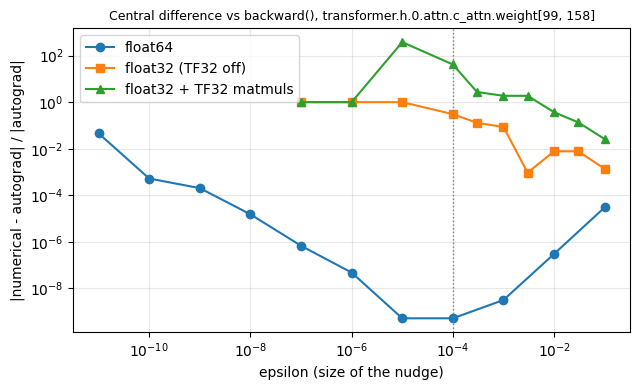

In [15]:
def sweep(m, param_name, index, eps_list, g_ref):
    p = m.get_parameter(param_name)
    v0 = p.data[index].item()
    out = []
    for e in eps_list:
        lp = L_at_m(m, p, index, v0 + e); vp = p.data[index].item()
        lm = L_at_m(m, p, index, v0 - e); vm = p.data[index].item()
        p.data[index] = v0
        gnum = (lp - lm) / (vp - vm) if vp != vm else float("nan")
        out.append({"eps": e, "numerical": gnum, "rel_err": abs(gnum - g_ref) / abs(g_ref)})
    return out

def L_at_m(m, p, index, value):
    p.data[index] = value
    with torch.no_grad():
        s, n = token_loss_sum(m(gx), gy)
    return (s / n).item()

sw64 = sweep(gmodel, gc["param"], idx, gc["eps_sweep_fp64"], g_auto)
m32 = GPT(cfg_model); m32.load_state_dict(INIT_STATE); m32 = m32.to(DEVICE).float().train()
m32.zero_grad(set_to_none=True)
s, n = token_loss_sum(m32(gx), gy); (s / n).backward()
g_auto32 = float(m32.get_parameter(gc["param"]).grad[idx])
sw32 = sweep(m32, gc["param"], idx, gc["eps_sweep_fp32"], g_auto)
sw32_tf32 = []
if DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    sw32_tf32 = sweep(m32, gc["param"], idx, gc["eps_sweep_fp32"], g_auto)
    torch.backends.cuda.matmul.allow_tf32 = False
print(f"reference (fp64 autograd) {g_auto:+.10e};  fp32 autograd {g_auto32:+.10e}  (rel diff {abs(g_auto32 - g_auto) / abs(g_auto):.1e})")
tab = pd.DataFrame(sw64)[["eps", "rel_err"]].rename(columns={"rel_err": "fp64 rel err"})
t32 = pd.DataFrame(sw32)[["eps", "rel_err"]].rename(columns={"rel_err": "fp32 rel err"})
tab = tab.merge(t32, on="eps", how="outer")
if sw32_tf32:
    tab = tab.merge(pd.DataFrame(sw32_tf32)[["eps", "rel_err"]].rename(columns={"rel_err": "fp32+TF32 rel err"}), on="eps", how="outer")
tab = tab.sort_values("eps", ascending=False)
print(tab.to_string(index=False, float_format=lambda v: f"{v:.2e}"))
best64 = min(sw64, key=lambda r: r["rel_err"])
err_at = {r["eps"]: r["rel_err"] for r in sw64}
e_big, e_small = max(err_at), min(err_at)
check("chosen eps sits in the valley: 100x below both ends of the fp64 sweep",
      err_at[eps] * 100 < err_at[e_big] and err_at[eps] * 100 < err_at[e_small],
      f"eps {eps:g}: {err_at[eps]:.1e} | eps {e_big:g}: {err_at[e_big]:.1e} | eps {e_small:g}: {err_at[e_small]:.1e} | best eps {best64['eps']:g}: {best64['rel_err']:.1e}")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.loglog([r["eps"] for r in sw64], [max(r["rel_err"], 1e-16) for r in sw64], "o-", label="float64")
ax.loglog([r["eps"] for r in sw32], [max(r["rel_err"], 1e-16) for r in sw32], "s-", label="float32 (TF32 off)")
if sw32_tf32:
    ax.loglog([r["eps"] for r in sw32_tf32], [max(r["rel_err"], 1e-16) for r in sw32_tf32], "^-", label="float32 + TF32 matmuls")
ax.axvline(eps, color="grey", ls=":", lw=1)
ax.set_xlabel("epsilon (size of the nudge)")
ax.set_ylabel("|numerical - autograd| / |autograd|")
ax.set_title(f"Central difference vs backward(), {gc['param']}{list(idx)}", fontsize=9)
ax.legend(); ax.grid(alpha=0.3, which="both")
fig.tight_layout(); fig.savefig("figures/gradcheck_eps_sweep.png", dpi=150); plt.show()

save_json("gradcheck.json", {
    "parameter": gc["param"], "index": idx, "selection_rule": "largest |grad| among query rows of block-0 c_attn at init",
    "dtype": "float64", "batch": {"B": gc["B"], "T": gc["T"], "seed": SEED + 1}, "eps": eps,
    "w": w0, "L_w": L0, "L_w_plus": Lp, "L_w_minus": Lm, "numerical": g_num, "autograd": g_auto,
    "abs_err": abs_err, "rel_err": rel_err, "restored_exactly": True, "restore_demo": RESTORE_DEMO,
    "random_sample": sample.to_dict(orient="records"), "eps_sweep_fp64": sw64, "eps_sweep_fp32": sw32,
    "eps_sweep_fp32_tf32": sw32_tf32, "autograd_fp32": g_auto32})
del gmodel, m32

**What this shows.** I nudged `transformer.h.0.attn.c_attn.weight[99, 158]` (a query weight for head 1, dim 35, input channel 158), starting from w = 0.0255171787.
A +1e-4 nudge lowered the loss by 1.826e-7, and -1e-4 raised it by the same amount. That is `-1.826167128627e-03` numerically against `-1.826167129583e-03` from `backward()`,
a relative error of 5.2e-10. Eight random scalars from other layers agree just as well (worst absolute error 5.8e-12).

Things I did not expect:

- I started with eps = 1e-6 out of habit. The sweep shows that this is already on the round-off side of the valley in float64 (4.8e-8 instead of 5.2e-10), so I moved to 1e-4.
- In float32 the best I could get was about 1e-3 relative. At eps = 1e-5 and below the numerical gradient is exactly zero: `L(w+eps)` and `L(w-eps)` round to the same fp32 number.
- With TF32 matmuls switched on, the check falls apart: for eps <= 3e-3 the relative error is 1.9 to 378. TF32 rounds the matmul inputs to 10 mantissa bits, so the loss jitters by more than the nudge moves it.
  nanoGPT's `train.py` turns TF32 on. A gradient check run in that setting would "fail" for reasons that have nothing to do with backprop.

This verifies a handful of scalars at the initial weights on one batch. It does not prove every gradient in the model is right.

# 3. Breaking gradient accumulation on purpose

Question: with micro-batches that hold different numbers of real tokens, how far is "average of the per-micro-batch averages"
from "sum of all token losses divided by all tokens", and does it change what the model learns?

First the standard toy arithmetic, reproduced:

In [16]:
cnt, avg = np.array([4, 4, 2]), np.array([2.0, 2.0, 5.0])
right = (cnt * avg).sum() / cnt.sum()
wrong = avg.mean()
print(f"token-weighted: {right:.4f}   average of averages: {wrong:.4f}   off by {100 * (wrong - right) / right:.1f}%")
check("Session 10 toy example reproduces 2.6 vs 3.0 (15.4%)",
      abs(right - 2.6) < 1e-12 and abs(wrong - 3.0) < 1e-12 and round(100 * (wrong - right) / right, 1) == 15.4)
eq = np.array([4, 4, 4])
check("with equal token counts the two agree exactly", (eq * avg).sum() / eq.sum() == avg.mean())

token-weighted: 2.6000   average of averages: 3.0000   off by 15.4%
  [ok] Session 10 toy example reproduces 2.6 vs 3.0 (15.4%)
  [ok] with equal token counts the two agree exactly


### Micro-batches that really are unequal

Speeches are sorted by length and cut into 4 equal-count buckets (length-grouped batching, which people use to cut padding).
Each accumulation window takes one micro-batch of 8 speeches from each bucket, in a shuffled order.
Sequences are right-padded to T=256; padded targets are -100 and excluded from the loss.

In [17]:
A = ACCUM
M = A["n_micro"]
sp_train, sp_val = D.speeches("train", A["T"]), D.speeches("val", A["T"])
buckets = length_buckets(sp_train, M)
edges = [len(sp_train[b[-1]]) - 1 for b in buckets]
print("bucket upper edges (valid targets per speech):", edges, "| speeches per bucket:", [len(b) for b in buckets])
windows = make_windows(sp_train, buckets, A["max_steps"], A["micro_batch"], SEED + 2)
WIN = [[pad_speeches([sp_train[i] for i in mb], A["T"]) for mb in w] for w in windows]
counts = np.array([[int((yy != IGNORE).sum()) for _, yy in w] for w in WIN])
ratio = counts.max(1) / counts.min(1)
print(f"{len(WIN)} windows x {M} micro-batches x {A['micro_batch']} sequences x T={A['T']}")
print(f"valid targets per micro-batch: min {counts.min()}, median {int(np.median(counts))}, max {counts.max()}")
print(f"largest / smallest micro-batch in a window: min {ratio.min():.1f}x, median {np.median(ratio):.1f}x, max {ratio.max():.1f}x")
check("every window has unequal valid-token counts", (counts.max(1) > counts.min(1)).all())
check("padding really is excluded: valid count < slots in every short micro-batch",
      (counts.min(1) < A["micro_batch"] * A["T"]).all())

w1 = counts[0]; N1 = w1.sum()
tw = pd.DataFrame({"micro-batch": range(1, M + 1), "valid targets": w1,
                   "padded slots": A["micro_batch"] * A["T"] - w1,
                   "weight per token, correct (1/N)": 1 / N1,
                   "weight per token, broken (1/(M*n_m))": 1 / (M * w1)})
tw["broken / correct"] = tw.iloc[:, 4] / tw.iloc[:, 3]
print("\nWindow 1, the first optimizer step:")
print(tw.to_string(index=False, float_format=lambda v: f"{v:.3g}"))

bucket upper edges (valid targets per speech): [48, 88, 180, 256] | speeches per bucket: [1570, 1571, 1571, 1571]


600 windows x 4 micro-batches x 8 sequences x T=256
valid targets per micro-batch: min 154, median 703, max 2048
largest / smallest micro-batch in a window: min 5.7x, median 7.8x, max 12.7x
  [ok] every window has unequal valid-token counts
  [ok] padding really is excluded: valid count < slots in every short micro-batch

Window 1, the first optimizer step:
 micro-batch  valid targets  padded slots  weight per token, correct (1/N)  weight per token, broken (1/(M*n_m))  broken / correct
           1            286          1762                         0.000286                              0.000874              3.06
           2           1799           249                         0.000286                              0.000139             0.486
           3            502          1546                         0.000286                              0.000498              1.74
           4            908          1140                         0.000286                              0.000275    

Two things have to be true before the comparison means anything: padding must not leak into real positions, and the
correct accumulation must equal the same examples run as one big batch. Both checked in float32 with TF32 off.

In [18]:
with section("accumulation_checks"):
    m = GPT(cfg_model); m.load_state_dict(INIT_STATE); m = m.to(DEVICE).train()
    fp32 = nullcontext()
    sp = min(sp_train, key=len) if QUICK else sorted(sp_train, key=len)[len(sp_train) // 3]
    xp, yp = pad_speeches([sp], A["T"])
    nv = len(sp) - 1
    with torch.no_grad():
        lg_pad = m(xp.to(DEVICE))[:, :nv]
        lg_unpad = m(xp[:, :nv].to(DEVICE))
    pad_diff = float((lg_pad - lg_unpad).abs().max())
    check("right padding does not change logits at real positions", pad_diff < 1e-5, f"max diff {pad_diff:.1e}, {nv} real of {A['T']}")

    def window_grads(state, window):
        mm = GPT(cfg_model); mm.load_state_dict(state); mm = mm.to(DEVICE).train()
        res = {}
        for mode in ["token", "mean_of_means"]:
            mm.zero_grad(set_to_none=True)
            r = accumulate(mm, window, mode, fp32, DEVICE)
            res[mode] = (flat_grad(mm), float(r["reported"]))
        mm.zero_grad(set_to_none=True)
        Lf = float(full_batch_backward(mm, window, fp32, DEVICE))
        gf = flat_grad(mm)
        out = {"full_batch_loss": Lf}
        for mode in res:
            out[mode] = {"reported_loss": res[mode][1], **compare_grads(res[mode][0], gf)}
        return out

    REF = {"unequal_window_1_at_init": window_grads(INIT_STATE, WIN[0])}
    egen = torch.Generator().manual_seed(SEED + 9)
    eq_window = [split_chunk(D.dense_chunk("train", A["micro_batch"], A["T"], egen)) for _ in range(M)]
    REF["equal_counts_window_at_init"] = window_grads(INIT_STATE, eq_window)

for k, r in REF.items():
    print(f"\n{k}: full-batch loss {r['full_batch_loss']:.6f}")
    for mode in ["token", "mean_of_means"]:
        q = r[mode]
        print(f"   {mode:<14} reported loss {q['reported_loss']:.6f} | grad vs full batch: rel L2 err {q['rel_l2_err']:.2e}, "
              f"cosine {q['cosine']:.6f}, norm ratio {q['norm_ratio']:.4f}")
u, e = REF["unequal_window_1_at_init"], REF["equal_counts_window_at_init"]
check("token-normalised accumulation == full batch gradient (unequal counts)", u["token"]["rel_l2_err"] < 1e-5, f"{u['token']['rel_l2_err']:.1e}")
check("token-normalised reported loss == full batch loss", abs(u["token"]["reported_loss"] - u["full_batch_loss"]) < 1e-5)
check("average-of-averages gradient differs from full batch (unequal counts)", u["mean_of_means"]["rel_l2_err"] > 1e-2, f"{u['mean_of_means']['rel_l2_err']:.1e}")
check("average-of-averages is correct when counts are equal", e["mean_of_means"]["rel_l2_err"] < 1e-5, f"{e['mean_of_means']['rel_l2_err']:.1e}")

  [ok] right padding does not change logits at real positions  (max diff 8.5e-07, 56 real of 256)



unequal_window_1_at_init: full-batch loss 4.273672
   token          reported loss 4.273672 | grad vs full batch: rel L2 err 3.17e-07, cosine 1.000000, norm ratio 1.0000
   mean_of_means  reported loss 4.261759 | grad vs full batch: rel L2 err 1.79e-01, cosine 0.984790, norm ratio 0.9412

equal_counts_window_at_init: full-batch loss 4.287900
   token          reported loss 4.287900 | grad vs full batch: rel L2 err 2.77e-07, cosine 1.000000, norm ratio 1.0000
   mean_of_means  reported loss 4.287900 | grad vs full batch: rel L2 err 2.77e-07, cosine 1.000000, norm ratio 1.0000
  [ok] token-normalised accumulation == full batch gradient (unequal counts)  (3.2e-07)
  [ok] token-normalised reported loss == full batch loss
  [ok] average-of-averages gradient differs from full batch (unequal counts)  (1.8e-01)
  [ok] average-of-averages is correct when counts are equal  (2.8e-07)


### The two real training runs

Same initial state dict (hash checked), same 600 windows in the same order, same AdamW, same schedule, same clipping, same bf16 autocast.
The only difference is the line that scales each micro-batch's loss before `backward()`.
Every 10 steps the broken run also computes the correct gradient at its *current* weights, so the gap can be measured directly.
Validation is token-weighted on held-out speeches, overall and split into the shortest and longest length buckets.

In [19]:
# held-out speeches in the range of the shortest / longest TRAIN bucket
short_hi = len(sp_train[buckets[0][-1]]) - 1
long_lo = len(sp_train[buckets[-1][0]]) - 1
v_short = [s_ for s_ in sp_val if len(s_) - 1 <= short_hi]
v_long = [s_ for s_ in sp_val if len(s_) - 1 >= long_lo]
def as_batches(lst, bs):
    return [pad_speeches(lst[i:i + bs], A["T"]) for i in range(0, len(lst), bs)]
VAL_ACC = {"val_all": as_batches(sp_val, A["val_batch"]), "val_short": as_batches(v_short, A["val_batch"]),
           "val_long": as_batches(v_long, A["val_batch"])}
print(f"val speeches: {len(sp_val)} | short (<= {short_hi} targets): {len(v_short)} | long (>= {long_lo} targets): {len(v_long)}")
check("short and long validation sets are non-empty", len(v_short) > 0 and len(v_long) > 0)

actx = autocast_ctx(DEVICE, A["precision"])
def run_accum(mode):
    torch.manual_seed(SEED)
    mm = GPT(cfg_model); mm.load_state_dict(INIT_STATE); mm = mm.to(DEVICE).train()
    h0 = state_hash(mm.state_dict())
    opt = mm.configure_optimizer(A["lr"], A["weight_decay"], A["betas"], DEVICE)
    def hook(step, model_, window):
        if mode == "token" or (step % A["cos_every"] and step != 1):
            return None
        g_saved = [p.grad.clone() for p in model_.parameters()]
        model_.zero_grad(set_to_none=True)
        accumulate(model_, window, "token", actx, DEVICE)
        g_tok = flat_grad(model_)
        for p, g in zip(model_.parameters(), g_saved):
            p.grad = g
        c = compare_grads(torch.cat([g.flatten().double() for g in g_saved]), g_tok)
        return {"cos_vs_correct": c["cosine"], "rel_err_vs_correct": c["rel_l2_err"]}
    t0 = time.time()
    log, vlog = train_loop(mm, opt, A, lambda s: WIN[s - 1], actx, DEVICE, probe=None, val_batches=VAL_ACC,
                           mode=mode, log_every_val=A["eval_every"], pre_step_hook=hook)
    return mm, pd.DataFrame(log), pd.DataFrame(vlog), h0, time.time() - t0

with section("accumulation_runs"):
    model_ok, log_ok, val_ok, h_ok, t_ok = run_accum("token")
    model_bad, log_bad, val_bad, h_bad, t_bad = run_accum("mean_of_means")
print(f"start hashes: correct {h_ok}  broken {h_bad};  wall {t_ok:.0f}s / {t_bad:.0f}s")
check("both runs start from the identical state dict", h_ok == h_bad == state_hash(INIT_STATE))
check("both runs logged every optimizer step", len(log_ok) == len(log_bad) == A["max_steps"])
check("both runs saw identical valid-token counts per step", (log_ok.valid_tokens.values == log_bad.valid_tokens.values).all())
check("correct run: reported loss IS the token-weighted loss", np.allclose(log_ok.loss, log_ok.true_loss))
check("losses finite in both runs", np.isfinite(log_ok.loss).all() and np.isfinite(log_bad.loss).all())
REF["unequal_last_window_at_end_of_correct_run"] = window_grads(
    {k: v.detach().cpu() for k, v in model_ok.state_dict().items()}, WIN[-1])
r = REF["unequal_last_window_at_end_of_correct_run"]
print(f"end of training, last window: token rel err {r['token']['rel_l2_err']:.1e}, "
      f"mean_of_means rel err {r['mean_of_means']['rel_l2_err']:.2e} (cos {r['mean_of_means']['cosine']:.4f})")
check("token accumulation still equals full batch at trained weights", r["token"]["rel_l2_err"] < 1e-5)

val speeches: 940 | short (<= 48 targets): 318 | long (>= 180 targets): 164
  [ok] short and long validation sets are non-empty


start hashes: correct 9c95ba38b5b8faa7  broken 9c95ba38b5b8faa7;  wall 32s / 34s
  [ok] both runs start from the identical state dict
  [ok] both runs logged every optimizer step
  [ok] both runs saw identical valid-token counts per step
  [ok] correct run: reported loss IS the token-weighted loss
  [ok] losses finite in both runs


end of training, last window: token rel err 1.1e-06, mean_of_means rel err 7.41e-01 (cos 0.7541)
  [ok] token accumulation still equals full batch at trained weights


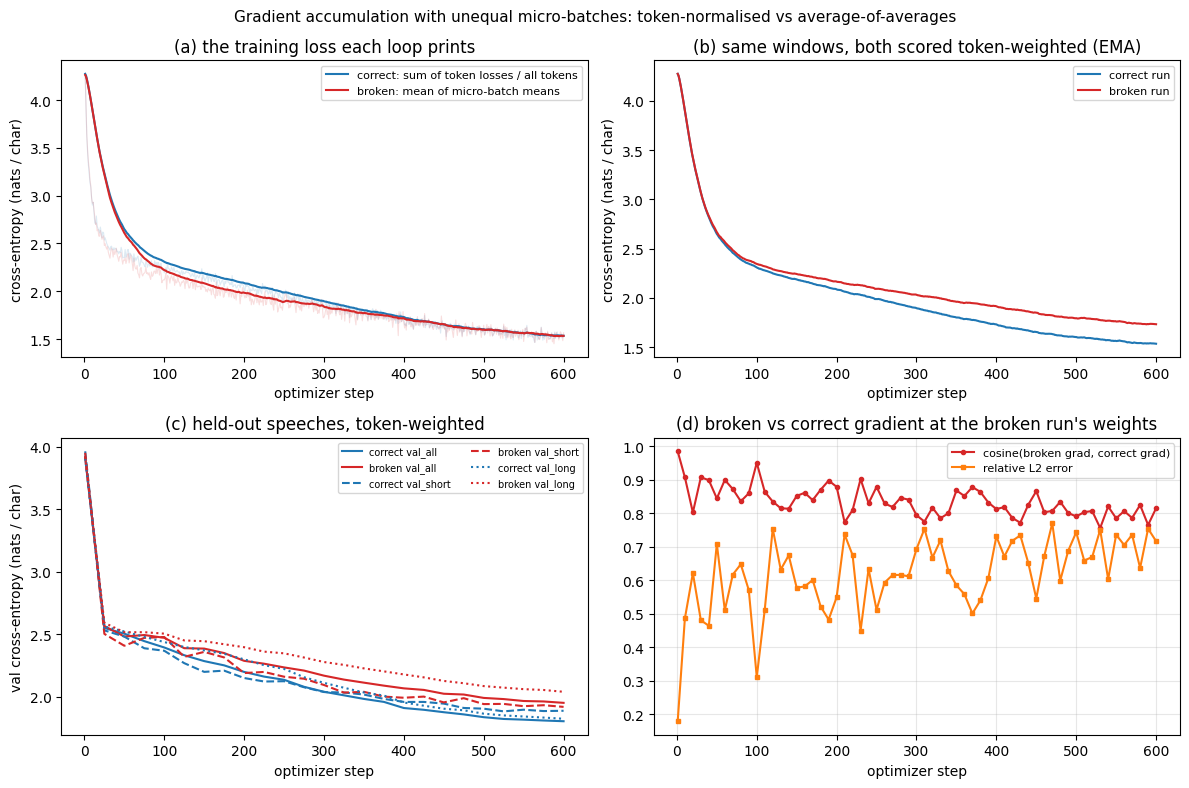

In [20]:
def ema(x, a=0.05):
    out, m_ = [], None
    for v in x:
        m_ = v if m_ is None else (1 - a) * m_ + a * v
        out.append(m_)
    return np.array(out)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
ax = axs[0, 0]
ax.plot(log_ok.step, log_ok.loss, color="C0", alpha=0.15, lw=0.8)
ax.plot(log_bad.step, log_bad.loss, color="C3", alpha=0.15, lw=0.8)
ax.plot(log_ok.step, ema(log_ok.loss), color="C0", label="correct: sum of token losses / all tokens")
ax.plot(log_bad.step, ema(log_bad.loss), color="C3", label="broken: mean of micro-batch means")
ax.set_title("(a) the training loss each loop prints")
ax.set_xlabel("optimizer step"); ax.set_ylabel("cross-entropy (nats / char)"); ax.legend(fontsize=8)
ax = axs[0, 1]
ax.plot(log_ok.step, ema(log_ok.true_loss), color="C0", label="correct run")
ax.plot(log_bad.step, ema(log_bad.true_loss), color="C3", label="broken run")
ax.set_title("(b) same windows, both scored token-weighted (EMA)")
ax.set_xlabel("optimizer step"); ax.set_ylabel("cross-entropy (nats / char)"); ax.legend(fontsize=8)
ax = axs[1, 0]
for col, ls in [("val_all", "-"), ("val_short", "--"), ("val_long", ":")]:
    ax.plot(val_ok.step, val_ok[col], color="C0", ls=ls, label=f"correct {col}")
    ax.plot(val_bad.step, val_bad[col], color="C3", ls=ls, label=f"broken {col}")
ax.set_title("(c) held-out speeches, token-weighted")
ax.set_xlabel("optimizer step"); ax.set_ylabel("val cross-entropy (nats / char)"); ax.legend(fontsize=7, ncol=2)
ax = axs[1, 1]
cs = log_bad.dropna(subset=["cos_vs_correct"])
ax.plot(cs.step, cs.cos_vs_correct, "o-", ms=3, color="C3", label="cosine(broken grad, correct grad)")
ax.plot(cs.step, cs.rel_err_vs_correct, "s-", ms=3, color="C1", label="relative L2 error")
ax.set_title("(d) broken vs correct gradient at the broken run's weights")
ax.set_xlabel("optimizer step"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle("Gradient accumulation with unequal micro-batches: token-normalised vs average-of-averages", fontsize=11)
fig.tight_layout(); fig.savefig("figures/accumulation_correct_vs_broken.png", dpi=150); plt.show()

In [21]:
last = slice(-100, None)
ACC_SUMMARY = {
    "windows": len(WIN), "micro_batches_per_window": M, "seqs_per_micro_batch": A["micro_batch"],
    "valid_targets_per_micro_batch": {"min": int(counts.min()), "median": float(np.median(counts)), "max": int(counts.max())},
    "max_over_min_in_window": {"min": float(ratio.min()), "median": float(np.median(ratio)), "max": float(ratio.max())},
    "window_1_counts": counts[0].tolist(),
    "reported_loss_last100_mean": {"correct": float(log_ok.loss.iloc[last].mean()), "broken": float(log_bad.loss.iloc[last].mean())},
    "true_loss_last100_mean": {"correct": float(log_ok.true_loss.iloc[last].mean()), "broken": float(log_bad.true_loss.iloc[last].mean())},
    "broken_reported_minus_true_last100": float((log_bad.loss - log_bad.true_loss).iloc[last].mean()),
    "final_val": {"correct": val_ok.iloc[-1].to_dict(), "broken": val_bad.iloc[-1].to_dict()},
    "cosine_broken_vs_correct": {"mean": float(cs.cos_vs_correct.mean()), "min": float(cs.cos_vs_correct.min())},
    "rel_err_broken_vs_correct": {"mean": float(cs.rel_err_vs_correct.mean())},
    "reference_checks": REF,
}
print(json.dumps({k: v for k, v in ACC_SUMMARY.items() if k != "reference_checks"}, indent=1))
fv_ok, fv_bad = val_ok.iloc[-1], val_bad.iloc[-1]
print("\nfinal validation (token-weighted):")
for col in ["val_all", "val_short", "val_long"]:
    print(f"   {col:<10} correct {fv_ok[col]:.4f}   broken {fv_bad[col]:.4f}   broken - correct {fv_bad[col] - fv_ok[col]:+.4f}")
save_json("accumulation.json", ACC_SUMMARY)
log_ok.assign(run="correct").drop(columns=[c for c in ["counts"] if c in log_ok]).to_csv("artifacts/accumulation_correct_steps.csv", index=False)
log_bad.assign(run="broken").to_csv("artifacts/accumulation_broken_steps.csv", index=False)
pd.concat([val_ok.assign(run="correct"), val_bad.assign(run="broken")]).to_csv("artifacts/accumulation_val.csv", index=False)
del model_ok, model_bad

{
 "windows": 600,
 "micro_batches_per_window": 4,
 "seqs_per_micro_batch": 8,
 "valid_targets_per_micro_batch": {
  "min": 154,
  "median": 703.5,
  "max": 2048
 },
 "max_over_min_in_window": {
  "min": 5.662251655629139,
  "median": 7.76114081996435,
  "max": 12.746753246753247
 },
 "window_1_counts": [
  286,
  1799,
  502,
  908
 ],
 "reported_loss_last100_mean": {
  "correct": 1.551718888282776,
  "broken": 1.552822185754776
 },
 "true_loss_last100_mean": {
  "correct": 1.551718888282776,
  "broken": 1.750086306333542
 },
 "broken_reported_minus_true_last100": -0.19726412057876586,
 "final_val": {
  "correct": {
   "step": 600.0,
   "val_all": 1.8039906553054113,
   "val_short": 1.8875523919350683,
   "val_long": 1.8238201661438347
  },
  "broken": {
   "step": 600.0,
   "val_all": 1.9509357168387247,
   "val_short": 1.9187761296983388,
   "val_long": 2.0393372629898
  }
 },
 "cosine_broken_vs_correct": {
  "mean": 0.8354271365616861,
  "min": 0.7559955308153925
 },
 "rel_err_brok

**What this shows.**

- In the first window the four micro-batches held 286, 1799, 502 and 908 real targets. Under average-of-averages, each token in the 286-target micro-batch counted 3.06x as much as it should, and each token in the 1799 one counted 0.49x.
- Against the same 32 sequences run as one batch, token-normalised accumulation matches to 3.2e-7 (fp32 round-off). Average-of-averages is off by 18% in L2 (cosine 0.985).
  With equal token counts the two are identical (2.8e-7), which is exactly how this bug hid.
- Panel (a) is the part that matters. The loss each loop *prints* is almost the same: 1.552 vs 1.553 over the last 100 steps. The broken loop is minimising the number it prints, so that number falls as nicely as the correct one.
  Scored per token on the same windows (b), the broken run is at 1.750, not 1.552. On held-out speeches it ends 0.147 nats/char worse: +0.216 on long speeches and +0.031 on short ones.
- I expected the broken run to at least win on short speeches, since it up-weights them. It does not; it just loses by less there. I don't have a clean explanation for that.
- The broken gradient drifts further from the correct one as training goes on: cosine 0.985 at step 1, then a median of 0.82 (minimum 0.76) after step 50 (d).

Both runs used the same initial state dict (hash 9c95ba38b5b8faa7), the same 600 windows and the same optimiser. Only the scaling line before `backward()` differed.

# 4. The main training run: grad norm from step one

Question: logging the global L2 grad norm (before clipping) at every optimizer step from step 1, is there a step where the norm moves
before the loss does, and can I defend that reading?

The training-batch loss is noisy because every step sees different text, so the loop also scores one *fixed* held-out probe batch
at every step, with the same weights the gradient was computed at. That gives a loss trace whose step-to-step changes come only from the weights.

In [22]:
with section("main_run"):
    torch.manual_seed(SEED)
    mm = GPT(cfg_model); mm.load_state_dict(INIT_STATE); mm = mm.to(DEVICE).train()
    opt = mm.configure_optimizer(MAIN["lr"], MAIN["weight_decay"], MAIN["betas"], DEVICE)
    mgen = torch.Generator().manual_seed(SEED + 3)
    def main_window(step):
        return [split_chunk(D.dense_chunk("train", MAIN["micro_batch"], MAIN["T"], mgen)) for _ in range(MAIN["grad_accum"])]
    vgen = torch.Generator().manual_seed(SEED + 4)
    VAL_MAIN = {"val": [split_chunk(D.dense_chunk("val", MAIN["val_batch"], MAIN["T"], vgen)) for _ in range(MAIN["n_val_batches"])]}
    PROBE = split_chunk(D.dense_chunk("val", MAIN["probe_batch"], MAIN["T"], torch.Generator().manual_seed(SEED + 5)))
    if DEVICE == "cuda":
        torch.cuda.reset_peak_memory_stats()
    t0 = time.time()
    mlog, mval = train_loop(mm, opt, MAIN, main_window, autocast_ctx(DEVICE, MAIN["precision"]), DEVICE,
                            probe=PROBE, val_batches=VAL_MAIN, mode="token", log_every_val=MAIN["eval_every"])
    MAIN_WALL = time.time() - t0
    PEAK_MEM_GB = torch.cuda.max_memory_allocated() / 2**30 if DEVICE == "cuda" else None
mlog, mval = pd.DataFrame(mlog), pd.DataFrame(mval)
mlog.to_csv("artifacts/train_metrics.csv", index=False)
mval.to_csv("artifacts/val_metrics.csv", index=False)
print(f"{len(mlog)} steps in {MAIN_WALL:.0f}s | peak GPU memory {PEAK_MEM_GB} GiB")
print(f"train loss step 1 {mlog.loss.iloc[0]:.4f} -> last {mlog.loss.iloc[-1]:.4f} | val {mval.val.iloc[0]:.4f} -> best {mval.val.min():.4f} (step {int(mval.step[mval.val.idxmin()])}) -> last {mval.val.iloc[-1]:.4f}")
print(f"grad norm step 1 {mlog.grad_norm.iloc[0]:.3f} | median {mlog.grad_norm.median():.3f} | max {mlog.grad_norm.max():.3f} (step {int(mlog.step[mlog.grad_norm.idxmax()])})")
print(f"clipping triggered on {int(mlog.clipped.sum())} of {len(mlog)} steps (threshold {MAIN['grad_clip']})")
check("grad norm recorded at every optimizer step from step 1", list(mlog.step) == list(range(1, MAIN["max_steps"] + 1)))
check("all grad norms and losses finite", np.isfinite(mlog.grad_norm).all() and np.isfinite(mlog.loss).all())
check("torch's clip_grad_norm_ total equals my own per-parameter norm on every step",
      np.allclose(mlog.grad_norm, mlog.grad_norm_manual, rtol=1e-3))
check("post-clip norm <= threshold (+fp slack) on every step", (mlog.grad_norm_post_clip <= MAIN["grad_clip"] * 1.001 + 1e-6).all())
check("every step processed the configured number of tokens", (mlog.valid_tokens == tokens_per_step).all())
if not QUICK:
    check("the model learned: val loss fell by more than 2 nats/char", mval.val.iloc[0] - mval.val.min() > 2.0)
    check("model fits comfortably on the GPU (< 50% of memory)", PEAK_MEM_GB < 0.5 * ENV["memory_GiB"], f"{PEAK_MEM_GB:.2f} GiB of {ENV['memory_GiB']}")

1500 steps in 88s | peak GPU memory 1.3070526123046875 GiB
train loss step 1 4.2826 -> last 0.6947 | val 4.0777 -> best 1.5366 (step 850) -> last 1.8924
grad norm step 1 14.871 | median 0.726 | max 14.871 (step 1)
clipping triggered on 159 of 1500 steps (threshold 1.0)
  [ok] grad norm recorded at every optimizer step from step 1
  [ok] all grad norms and losses finite
  [ok] torch's clip_grad_norm_ total equals my own per-parameter norm on every step
  [ok] post-clip norm <= threshold (+fp slack) on every step
  [ok] every step processed the configured number of tokens
  [ok] the model learned: val loss fell by more than 2 nats/char
  [ok] model fits comfortably on the GPU (< 50% of memory)  (1.31 GiB of 22.06)


### Looking for a step where the norm moved first

What the trace offers, before any rule: the norm starts far above the clip threshold on step 1, falls below 1 within ~30 steps, and later
drifts *up* again while the training loss keeps falling. The held-out probe loss bottoms out and then rises: the model starts memorising the 1M-character
training set. So the candidate is the turn into overfitting: did the norm turn before the held-out loss did?

Single-step spikes are the other obvious candidates. I did not analyse them; the turn into overfitting is the larger, slower movement and the one a rule can be tested on.

The rule, chosen after looking at a pilot run of this exact configuration (same seeds, so not an out-of-sample test) and applied unchanged here:

1. **Retrospective turning point.** Centred rolling median of each series (several window sizes), argmin after step 300 (past warm-up and the early plateau).
2. **Causal alarm** (uses only past steps, so it is something a dashboard could actually do): trailing rolling median; alarm on the first step after 300 where it
   exceeds its own running minimum by k standard errors (noise from the MAD of the residual around the smoothed curve). Same rule for grad norm and probe loss.

The event is the grad-norm alarm at w=101, k=3; the other (w, k) rows are there so the choice can be judged.

Retrospective turning points (centred rolling median, argmin after step 300):
 window  grad_norm_min_step  probe_loss_min_step  norm_leads_by
     25                 721                  856            135
     51                 734                  841            107
    101                 712                  818            106
    151                 734                  794             60
full validation set (every 50 steps): lowest at step 850, 1.5366

Causal alarms (trailing median exceeds its running min by k standard errors):
 window  k  grad_norm_alarm  probe_loss_alarm  lead  se_grad_norm  se_probe
     25  3              316               529   213        0.0085    0.0016
     25  5              400               882   482        0.0085    0.0016
     51  3              351               892   541        0.0064    0.0014
     51  5              833               899    66        0.0064    0.0014
    101  3              830               904    74        0.0047    0.0010
  

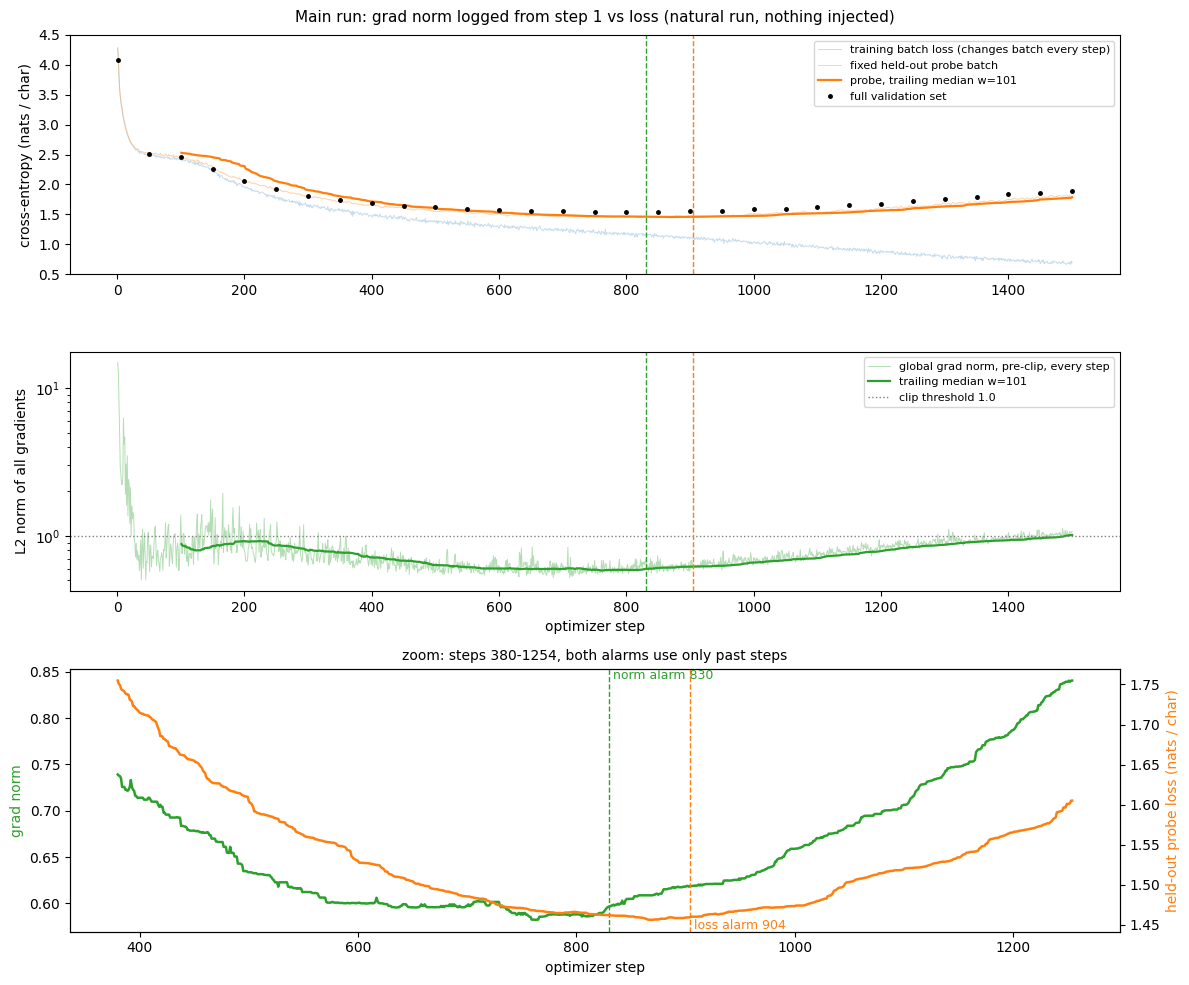

In [23]:
START = 300 if not QUICK else 5
st = mlog.step.values

def centred(x, w):
    return pd.Series(x).rolling(w, center=True, min_periods=w // 2).median().values

def trailing_alarm(x, w, k, start=START):
    x = np.asarray(x, dtype=float)
    tr = pd.Series(x).rolling(w).median().values
    resid = x - centred(x, w)
    r = resid[start:]
    sigma = 1.4826 * np.nanmedian(np.abs(r - np.nanmedian(r)))
    se = 1.2533 * sigma / np.sqrt(w)            # standard error of a median of w noisy points
    idx = np.arange(len(x))
    runmin = np.minimum.accumulate(np.where(idx >= start, np.nan_to_num(tr, nan=np.inf), np.inf))
    hit = np.where((idx >= start) & (tr > runmin + k * se))[0]
    return (int(st[hit[0]]) if len(hit) else None), se, tr

TURN = []
for w in [25, 51, 101, 151] if not QUICK else [5]:
    g_s, p_s = centred(mlog.grad_norm.values, w), centred(mlog.probe_loss.values, w)
    sub = np.arange(len(st)) >= START
    gi, pi_ = np.nanargmin(np.where(sub, g_s, np.inf)), np.nanargmin(np.where(sub, p_s, np.inf))
    TURN.append({"window": w, "grad_norm_min_step": int(st[gi]), "probe_loss_min_step": int(st[pi_]),
                 "norm_leads_by": int(st[pi_] - st[gi])})
TURN = pd.DataFrame(TURN)
print("Retrospective turning points (centred rolling median, argmin after step %d):" % START)
print(TURN.to_string(index=False))
val_min_step = int(mval.step[mval.val.idxmin()])
print(f"full validation set (every {MAIN['eval_every']} steps): lowest at step {val_min_step}, {mval.val.min():.4f}")

ALARMS = []
for w, k in ([(25, 3), (25, 5), (51, 3), (51, 5), (101, 3), (101, 5)] if not QUICK else [(5, 3)]):
    a_g, se_g, _ = trailing_alarm(mlog.grad_norm.values, w, k)
    a_p, se_p, _ = trailing_alarm(mlog.probe_loss.values, w, k)
    ALARMS.append({"window": w, "k": k, "grad_norm_alarm": a_g, "probe_loss_alarm": a_p,
                   "lead": (a_p - a_g) if (a_g is not None and a_p is not None) else None,
                   "se_grad_norm": se_g, "se_probe": se_p})
ALARMS = pd.DataFrame(ALARMS)
print("\nCausal alarms (trailing median exceeds its running min by k standard errors):")
print(ALARMS.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

W_EV, K_EV = (101, 3) if not QUICK else (5, 3)
ev_g, se_g, tr_g = trailing_alarm(mlog.grad_norm.values, W_EV, K_EV)
ev_p, se_p, tr_p = trailing_alarm(mlog.probe_loss.values, W_EV, K_EV)
EVENT = {"rule": f"trailing median w={W_EV}, alarm at running min + {K_EV} SE, after step {START}",
         "event_step": ev_g, "loss_reacts_step": ev_p,
         "lead_steps": (ev_p - ev_g) if (ev_g and ev_p) else None, "natural_or_induced": "natural (no intervention)",
         "turning_points": TURN.to_dict(orient="records"), "alarms": ALARMS.to_dict(orient="records"),
         "val_min_step": val_min_step}
if ev_g is not None:
    row = mlog.set_index("step")
    gmin_step = int(st[np.nanargmin(np.where(np.arange(len(st)) >= START, tr_g, np.inf))])
    EVENT.update({
        "event_grad_norm": float(row.loc[ev_g, "grad_norm"]),
        "trailing_median_grad_norm_at_event": float(tr_g[ev_g - 1]),
        "trailing_median_grad_norm_min": float(np.nanmin(np.where(np.arange(len(st)) >= START, tr_g, np.inf))),
        "trailing_median_grad_norm_min_step": gmin_step,
        "probe_loss_trailing_at_event": float(tr_p[ev_g - 1]),
        "probe_loss_trailing_min_so_far_at_event": float(np.nanmin(tr_p[START:ev_g])),
        "train_loss_trailing_at_event": float(pd.Series(mlog.loss.values).rolling(W_EV).median().values[ev_g - 1]),
        "lr_at_event": float(row.loc[ev_g, "lr"]),
        "clipped_steps_first_50": int(mlog.clipped.iloc[:50].sum()),
        "per_block_norm_change_min_to_event": {
            c: float(pd.Series(mlog[c].values).rolling(W_EV).median().values[ev_g - 1] /
                     pd.Series(mlog[c].values).rolling(W_EV).median().values[gmin_step - 1])
            for c in mlog.columns if c.startswith("gn_")},
    })
    if ev_p:
        EVENT["grad_norm_trailing_at_loss_reaction"] = float(tr_g[ev_p - 1])
    print(f"\nEvent: grad-norm alarm at step {ev_g}; probe-loss alarm at step {ev_p}; lead {EVENT['lead_steps']} steps")
    print(f"  trailing-median grad norm: min {EVENT['trailing_median_grad_norm_min']:.4f} (step {gmin_step}) -> "
          f"{EVENT['trailing_median_grad_norm_at_event']:.4f} at the event (+{100 * (EVENT['trailing_median_grad_norm_at_event'] / EVENT['trailing_median_grad_norm_min'] - 1):.1f}%)")
    print(f"  probe loss at the event: trailing median {EVENT['probe_loss_trailing_at_event']:.4f} vs best so far {EVENT['probe_loss_trailing_min_so_far_at_event']:.4f} (still flat)")
    print(f"  train loss at the event {EVENT['train_loss_trailing_at_event']:.4f} and still falling; lr {EVENT['lr_at_event']:.2e}")
    print("  per-block grad-norm growth from the norm minimum to the event (trailing medians):")
    for c, v in sorted(EVENT["per_block_norm_change_min_to_event"].items(), key=lambda kv: -kv[1]):
        print(f"     {c[3:]:<12} x{v:.3f}")
    check("event is natural: no data or weights were altered during the main run", True)
    if not QUICK:
        check("in the retrospective analysis the norm turns before the probe loss for every window", (TURN.norm_leads_by > 0).all(),
              TURN.norm_leads_by.tolist())
        check("causal grad-norm alarm precedes the causal probe-loss alarm", ev_p is not None and ev_p > ev_g, f"{ev_g} -> {ev_p}")
save_json("grad_norm_event.json", EVENT)

fig = plt.figure(figsize=(12, 10))
gsp = fig.add_gridspec(3, 1, height_ratios=[1, 1, 1.1])
ax1 = fig.add_subplot(gsp[0]); ax2 = fig.add_subplot(gsp[1], sharex=ax1); ax3 = fig.add_subplot(gsp[2])
ax1.plot(st, mlog.loss, color="C0", alpha=0.25, lw=0.7, label="training batch loss (changes batch every step)")
ax1.plot(st, mlog.probe_loss, color="C1", alpha=0.35, lw=0.7, label="fixed held-out probe batch")
ax1.plot(st, tr_p, color="C1", lw=1.6, label=f"probe, trailing median w={W_EV}")
ax1.plot(mval.step, mval.val, "k.", ms=5, label="full validation set")
ax1.set_ylabel("cross-entropy (nats / char)"); ax1.legend(fontsize=8, loc="upper right"); ax1.set_ylim(0.5, 4.5)
ax2.semilogy(st, mlog.grad_norm, color="C2", alpha=0.35, lw=0.7, label="global grad norm, pre-clip, every step")
ax2.semilogy(st, tr_g, color="C2", lw=1.6, label=f"trailing median w={W_EV}")
ax2.axhline(MAIN["grad_clip"], color="grey", ls=":", lw=1, label=f"clip threshold {MAIN['grad_clip']}")
ax2.set_ylabel("L2 norm of all gradients"); ax2.set_xlabel("optimizer step"); ax2.legend(fontsize=8, loc="upper right")
for ax in (ax1, ax2):
    if ev_g: ax.axvline(ev_g, color="C2", ls="--", lw=1)
    if ev_p: ax.axvline(ev_p, color="C1", ls="--", lw=1)
lo, hi = (max(START, (ev_g or START) - 450), min(len(st), (ev_p or len(st)) + 350))
zs = (st >= lo) & (st <= hi)
ax3.plot(st[zs], tr_g[zs], color="C2", lw=1.8, label="grad norm (trailing median)")
ax3.set_ylabel("grad norm", color="C2")
ax3b = ax3.twinx()
ax3b.plot(st[zs], tr_p[zs], color="C1", lw=1.8, label="probe loss (trailing median)")
ax3b.set_ylabel("held-out probe loss (nats / char)", color="C1")
if ev_g:
    ax3.axvline(ev_g, color="C2", ls="--", lw=1); ax3.text(ev_g, ax3.get_ylim()[1], f" norm alarm {ev_g}", color="C2", va="top", fontsize=9)
if ev_p:
    ax3.axvline(ev_p, color="C1", ls="--", lw=1); ax3.text(ev_p, ax3.get_ylim()[0], f" loss alarm {ev_p}", color="C1", va="bottom", fontsize=9)
ax3.set_xlabel("optimizer step"); ax3.set_title(f"zoom: steps {lo}-{hi}, both alarms use only past steps", fontsize=10)
fig.suptitle("Main run: grad norm logged from step 1 vs loss (natural run, nothing injected)", fontsize=11)
fig.tight_layout(); fig.savefig("figures/gradnorm_vs_loss.png", dpi=150); plt.show()

**What this shows, and what it doesn't.**

- The norm was 14.87 at step 1. The first 26 steps were all clipped, 30 of the first 50, and 159 of 1500 overall. Clipping from step one is not a formality here.
- The event: the trailing-median grad norm bottomed at 0.582 (step 762), and the causal alarm fired at **step 830**, when it had risen 2.4%.
  At that step the held-out probe loss was at its best value so far (1.462) and the training loss was still falling (1.185). The probe-loss alarm fired at **step 904, 74 steps later**.
  The full validation set, scored every 50 steps, bottomed at step 850. Looking back with centred windows of 25 to 151 steps, the norm turned 60 to 135 steps before the probe loss.
- The rise sat in the transformer blocks (h.0 to h.5 up 3.8 to 6.4%), while the embedding and final LayerNorm gradients were flat or slightly down.
- This happened in a normal run; nothing was injected, so I did not need a stress test.

What I can't claim: the move is small and only shows up after heavy smoothing. With short windows the same rule fires at steps 316, 351 and 400 on bumps that never reached the loss.
The learning rate is also decaying (5.2e-4 at the event), so part of the rise could be the schedule rather than overfitting.
This is one natural instance of the norm leading the held-out loss into overfitting, not evidence that grad norm predicts loss in general.
The window and threshold were picked after looking at the pilot trace, and this run has the same seeds, so it is not an out-of-sample test of the rule.

# 5. MFU, measured

Question: what fraction of this GPU's dense bf16 tensor-core peak does the training step actually use?

`MFU = 6 * N * tokens_per_second / peak_FLOPs_per_second`. N is the number of weights; 6N is about 2N FLOPs per token for the forward
matmuls plus 4N for backward (gradient w.r.t. activations and w.r.t. weights). Tokens are *useful* tokens: every target in a dense chunk is real, so tokens = steps x accum x B x T.

Timing: a fresh model and optimizer, warm-up steps first, then a timed block bracketed by `torch.cuda.synchronize()`.
Data download, model construction, compilation and evaluation are outside the timed block.

The denominator: Modal's "A10" is the **A10G**, an AWS variant of the A10, and its peak is not the A10's. From NVIDIA's A10G datasheet
(d1.awsstatic.com/product-marketing/ec2/NVIDIA_AWS_A10G_DataSheet_FINAL_02_17_2022.pdf): FP32 35 TFLOPS, TF32 tensor 35 (70 with sparsity),
BF16/FP16 tensor **70 TFLOPS dense** (140 with sparsity). The NVIDIA A10 product page lists BF16 125 dense (250 sparse). I use the dense
number for the GPU the code reports, and the cell refuses to run on a GPU it has no entry for.

In [24]:
PEAK_DENSE = {
    "NVIDIA A10G": {"bf16": 70e12, "fp32_tf32": 35e12, "fp32": 35e12,
                    "source": "NVIDIA A10G datasheet (AWS, 2022-02-17): FP32 35 TF; TF32 35|70*; BF16 70|140*; *=sparsity"},
    "NVIDIA A10": {"bf16": 125e12, "fp32_tf32": 62.5e12, "fp32": 31.2e12,
                   "source": "nvidia.com/en-us/data-center/products/a10-gpu: FP32 31.2; TF32 62.5|125*; BF16 125|250*"},
}
MFU_OUT = {}
if DEVICE != "cuda":
    print("MFU needs a CUDA GPU; skipped in this run.")
else:
    gpu = torch.cuda.get_device_name(0)
    check("the GPU in use has a datasheet entry for the MFU denominator", gpu in PEAK_DENSE, gpu)
    PEAK = PEAK_DENSE[gpu]
    print(gpu, "|", PEAK["source"])

    def bench_mm(Mr, K, Nc, dtype, iters=50):
        a = torch.randn(Mr, K, device="cuda", dtype=dtype); b = torch.randn(K, Nc, device="cuda", dtype=dtype)
        for _ in range(5): a @ b
        torch.cuda.synchronize(); t0 = time.perf_counter()
        for _ in range(iters): a @ b
        torch.cuda.synchronize()
        return 2 * Mr * K * Nc / ((time.perf_counter() - t0) / iters)
    with section("mfu_matmul"):
        R = MAIN["micro_batch"] * MAIN["T"]
        mm_rows = [("8192 x 8192 x 8192 (big square)", 8192, 8192, 8192)] + [
            (f"{nm}: [{R}x{k}] @ [{k}x{n}]", R, k, n) for nm, k, n in
            [("c_attn", C, 3 * C), ("attn c_proj", C, C), ("mlp c_fc", C, 4 * C), ("mlp c_proj", 4 * C, C), ("lm_head", C, V)]]
        MM = []
        for nm, a_, b_, c_ in mm_rows:
            f = bench_mm(a_, b_, c_, torch.bfloat16)
            MM.append({"matmul (bf16)": nm, "TFLOP/s": f / 1e12, "% of 70 TF peak": 100 * f / PEAK["bf16"]})
        torch.backends.cuda.matmul.allow_tf32 = True
        f_tf32 = bench_mm(8192, 8192, 8192, torch.float32, iters=10)
        torch.backends.cuda.matmul.allow_tf32 = False
        f_fp32 = bench_mm(8192, 8192, 8192, torch.float32, iters=10)
    MM = pd.DataFrame(MM)
    print(MM.to_string(index=False, float_format=lambda v: f"{v:.1f}"))
    print(f"fp32 8192^3: TF32 on {f_tf32/1e12:.1f} TFLOP/s, TF32 off {f_fp32/1e12:.1f} TFLOP/s (datasheet 35 / 35)")
    check("no measured bf16 matmul exceeds the datasheet peak (denominator is not too small)",
          MM["TFLOP/s"].max() * 1e12 <= PEAK["bf16"], f"best {MM['TFLOP/s'].max():.1f} TF")
    check("fp32 and TF32 matmuls stay under their datasheet peaks", f_fp32 <= PEAK["fp32"] and f_tf32 <= PEAK["fp32_tf32"],
          f"{f_fp32/1e12:.1f} / {f_tf32/1e12:.1f} TF")
    MFU_OUT["matmul_ceiling"] = MM.to_dict(orient="records")
    MFU_OUT["fp32_8192_tf32_on_TF"] = f_tf32 / 1e12
    MFU_OUT["fp32_8192_tf32_off_TF"] = f_fp32 / 1e12

  [ok] the GPU in use has a datasheet entry for the MFU denominator  (NVIDIA A10G)
NVIDIA A10G | NVIDIA A10G datasheet (AWS, 2022-02-17): FP32 35 TF; TF32 35|70*; BF16 70|140*; *=sparsity


                       matmul (bf16)  TFLOP/s  % of 70 TF peak
     8192 x 8192 x 8192 (big square)     66.6             95.2
     c_attn: [8192x384] @ [384x1152]     42.7             60.9
 attn c_proj: [8192x384] @ [384x384]     43.1             61.6
   mlp c_fc: [8192x384] @ [384x1536]     46.1             65.8
mlp c_proj: [8192x1536] @ [1536x384]     50.9             72.8
      lm_head: [8192x384] @ [384x65]     12.1             17.3
fp32 8192^3: TF32 on 34.0 TFLOP/s, TF32 off 23.0 TFLOP/s (datasheet 35 / 35)
  [ok] no measured bf16 matmul exceeds the datasheet peak (denominator is not too small)  (best 66.6 TF)
  [ok] fp32 and TF32 matmuls stay under their datasheet peaks  (23.0 / 34.0 TF)


In [25]:
if DEVICE == "cuda":
    N = N_total
    attn_flops_per_token = 12 * L * C * MAIN["T"]   # QK^T and AV, forward+backward, as nanoGPT's estimate_mfu counts them
    N_matmul = N - TMAX * C                          # wpe is a lookup; wte is used by the lm_head matmul so it stays
    def mfu_row(name, tps, peak):
        return {"config": name, "tok/s": tps, "achieved TFLOP/s (6N)": 6 * N * tps / 1e12,
                "MFU % (6N)": 100 * 6 * N * tps / peak,
                "MFU % (6N_matmul + attention)": 100 * (6 * N_matmul + attn_flops_per_token) * tps / peak}

    def fresh(compile_=False):
        m_ = GPT(cfg_model); m_.load_state_dict(INIT_STATE); m_ = m_.to(DEVICE).train()
        o_ = m_.configure_optimizer(MAIN["lr"], MAIN["weight_decay"], MAIN["betas"], DEVICE)
        return (torch.compile(m_) if compile_ else m_), o_

    def staged(mb, accum, n, seed=SEED + 11):
        g_ = torch.Generator().manual_seed(seed)
        return [[tuple(t.to(DEVICE) for t in split_chunk(D.dense_chunk("train", mb, MAIN["T"], g_))) for _ in range(accum)]
                for _ in range(n)]

    n_w, n_t = MFU["n_warm"], MFU["n_timed"]
    bctx = autocast_ctx(DEVICE, "bf16")
    RUNS = []
    with section("mfu_bench"):
        # A: exactly the main loop's step: batches sampled on the CPU and copied every step
        m_, o_ = fresh(); step = make_fast_step(m_, o_, bctx, MAIN["grad_clip"])
        g_ = torch.Generator().manual_seed(SEED + 12)
        live = lambda i: [tuple(t.to(DEVICE) for t in split_chunk(D.dense_chunk("train", MAIN["micro_batch"], MAIN["T"], g_)))
                          for _ in range(MAIN["grad_accum"])]
        RUNS.append(("A. main config (B=32 x accum 2), CPU sampling + H2D each step", time_steps(step, live, n_w, n_t, DEVICE), PEAK["bf16"]))
        # B: same step, batches already on the GPU
        W = staged(MAIN["micro_batch"], MAIN["grad_accum"], 32)   # a pool of 32 distinct windows, cycled
        RUNS.append(("B. main config, batches pre-staged on GPU", time_steps(step, lambda i: W[i % 32], n_w, n_t, DEVICE), PEAK["bf16"]))
        # C: forward + backward only
        def fwd_bwd(window):
            Ntok = sum(int(yy.numel()) for _, yy in window)
            for xx, yy in window:
                with bctx:
                    lg_ = m_(xx)
                s_, _ = token_loss_sum(lg_, yy); (s_ / Ntok).backward()
            m_.zero_grad(set_to_none=True)
            return Ntok
        RUNS.append(("C. main config, forward+backward only (no clip, no AdamW)", time_steps(fwd_bwd, lambda i: W[i % 32], n_w, n_t, DEVICE), PEAK["bf16"]))
        del m_, o_
        # D: micro-batch sweep, accum 1, pre-staged
        for mb in MFU["batch_sweep"]:
            m_, o_ = fresh(); step = make_fast_step(m_, o_, bctx, MAIN["grad_clip"])
            Wb = staged(mb, 1, 32)
            RUNS.append((f"D. micro-batch {mb} x accum 1 ({mb * MAIN['T']:,} tok/step), pre-staged",
                         time_steps(step, lambda i: Wb[i % 32], n_w, n_t, DEVICE), PEAK["bf16"]))
            del m_, o_, Wb
        # E: torch.compile at the main config
        try:
            m_, o_ = fresh(compile_=True); step = make_fast_step(m_, o_, bctx, MAIN["grad_clip"])
            t_c0 = time.time(); step(W[0]); torch.cuda.synchronize(); compile_s = time.time() - t_c0
            RUNS.append(("E. main config + torch.compile, pre-staged", time_steps(step, lambda i: W[i % 32], n_w, n_t, DEVICE), PEAK["bf16"]))
            MFU_OUT["compile_first_step_s"] = compile_s
            del m_, o_
        except Exception as ex:
            MFU_OUT["compile_error"] = repr(ex)[:500]
            print("torch.compile failed:", repr(ex)[:300])
        # F: precision at the main config (each against its own peak)
        for prec, label, peak_ in [("fp32", "fp32, TF32 off", PEAK["fp32"]), ("tf32", "fp32 with TF32 matmuls", PEAK["fp32_tf32"])]:
            torch.backends.cuda.matmul.allow_tf32 = prec == "tf32"
            m_, o_ = fresh(); step = make_fast_step(m_, o_, nullcontext(), MAIN["grad_clip"])
            RUNS.append((f"F. main config, {label}, pre-staged", time_steps(step, lambda i: W[i % 32], n_w, n_t, DEVICE), peak_))
            del m_, o_
        torch.backends.cuda.matmul.allow_tf32 = False

    MFU_TAB = pd.DataFrame([{**mfu_row(nm, r["tok_per_s"], pk), "ms/step": r["ms_per_step"], "timed steps": r["steps"], "timed s": r["seconds"],
                             "peak TF used": pk / 1e12} for nm, r, pk in RUNS])
    print(f"N = {N:,} (all trainable params, tied wte/lm_head once) -> 6N = {6 * N / 1e6:.1f} MFLOP per token")
    print(f"refined: 6*N_matmul + attention = {(6 * N_matmul + attn_flops_per_token) / 1e6:.1f} MFLOP per token "
          f"(N_matmul drops wpe; attention adds 12*L*C*T = {attn_flops_per_token / 1e6:.1f})")
    print(MFU_TAB.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
    main_logged_tps = float(mlog.tok_per_s.iloc[50:].median())
    print(f"\nmain training run, per-step logged tok/s (steps 51+, median, includes per-step .item() syncs): {main_logged_tps:,.0f}")
    for _, r in MFU_TAB.iterrows():
        check(f"timed window >= 5 s: {r['config'][:48]}", r["timed s"] >= 5.0, f"{r['timed s']:.1f}s, {int(r['timed steps'])} steps")
    MFU_OUT.update({"gpu": gpu, "peak": PEAK, "N": N, "N_matmul": N_matmul, "attn_flops_per_token": attn_flops_per_token,
                    "flops_per_token_6N": 6 * N, "timing": "warm-up %d steps + 5 calibration steps, then max(%d steps, ~6 s), cuda.synchronize before/after" % (n_w, n_t),
                    "table": MFU_TAB.to_dict(orient="records"), "main_run_logged_tok_per_s_median": main_logged_tps})

N = 10,745,088 (all trainable params, tied wte/lm_head once) -> 6N = 64.5 MFLOP per token
refined: 6*N_matmul + attention = 71.0 MFLOP per token (N_matmul drops wpe; attention adds 12*L*C*T = 7.1)
                                                       config      tok/s  achieved TFLOP/s (6N)  MFU % (6N)  MFU % (6N_matmul + attention)  ms/step  timed steps  timed s  peak TF used
A. main config (B=32 x accum 2), CPU sampling + H2D each step 349,210.58                  22.51       32.16                          35.40    46.92          128     6.01         70.00
                    B. main config, batches pre-staged on GPU 351,964.22                  22.69       32.42                          35.68    46.55          129     6.00         70.00
    C. main config, forward+backward only (no clip, no AdamW) 363,733.24                  23.45       33.50                          36.87    45.04          134     6.04         70.00
      D. micro-batch 8 x accum 1 (2,048 tok/step), pre-staged 209,1

Where does the time go? A short `torch.profiler` capture of config B: total time inside CUDA kernels versus wall-clock time,
kernels grouped by what they do, and how many kernels one optimizer step launches.

In [26]:
if DEVICE == "cuda":
    from torch.profiler import profile, ProfilerActivity
    m_, o_ = fresh(); step = make_fast_step(m_, o_, bctx, MAIN["grad_clip"])
    for i in range(5): step(W[i])
    torch.cuda.synchronize()
    nprof = MFU["profile_steps"]
    with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA]) as prof:
        for i in range(nprof): step(W[(5 + i) % 32])
        torch.cuda.synchronize()
    kern = []
    for e_ in prof.events():
        if e_.device_type.name == "CUDA":
            kern.append((e_.name, e_.time_range.elapsed_us()))
    kdf = pd.DataFrame(kern, columns=["kernel", "us"])
    def cat(nm):
        n_ = nm.lower()
        if "memcpy" in n_ or "memset" in n_: return "memcpy/memset"
        if any(s in n_ for s in ["flash", "fmha", "attention", "efficient_attention", "mem_eff"]): return "attention kernel (SDPA)"
        if any(s in n_ for s in ["gemm", "cutlass", "xmma", "s16816", "cublas", "sm80_", "sm86_", "ampere_"]): return "matmul (GEMM)"
        if any(s in n_ for s in ["adam", "multi_tensor"]): return "optimizer (fused AdamW, foreach)"
        if "norm" in n_ and "layer" in n_: return "layernorm"
        if "softmax" in n_ or "cross_entropy" in n_ or "nll" in n_ or "log_softmax" in n_: return "softmax / loss"
        if "reduce" in n_: return "reductions (incl. grad-norm)"
        return "elementwise / other"
    kdf["category"] = kdf.kernel.map(cat)
    per_step_ms = MFU_TAB.loc[MFU_TAB.config.str.startswith("B."), "ms/step"].iloc[0]
    kernel_ms_per_step = kdf.us.sum() / 1000 / nprof
    breakdown = (kdf.groupby("category").agg(ms_per_step=("us", lambda s: s.sum() / 1000 / nprof), launches_per_step=("us", lambda s: len(s) / nprof))
                 .sort_values("ms_per_step", ascending=False))
    breakdown["% of kernel time"] = 100 * breakdown.ms_per_step / breakdown.ms_per_step.sum()
    print(breakdown.to_string(float_format=lambda v: f"{v:.2f}"))
    print(f"\nGPU kernel time per step {kernel_ms_per_step:.1f} ms vs unprofiled wall time per step {per_step_ms:.1f} ms "
          f"-> GPU busy {100 * kernel_ms_per_step / per_step_ms:.0f}% | {len(kdf) / nprof:.0f} kernel launches per optimizer step")
    top = kdf.groupby("kernel").us.agg(["sum", "count"]).sort_values("sum", ascending=False).head(8)
    top["ms_per_step"] = top["sum"] / 1000 / nprof
    print("\ntop kernels:"); print(top[["ms_per_step", "count"]].to_string(float_format=lambda v: f"{v:.2f}"))
    MFU_OUT["profile"] = {"kernel_ms_per_step": kernel_ms_per_step, "wall_ms_per_step_unprofiled": per_step_ms,
                          "gpu_busy_pct": 100 * kernel_ms_per_step / per_step_ms, "launches_per_step": len(kdf) / nprof,
                          "breakdown": breakdown.reset_index().to_dict(orient="records")}
    del m_, o_
    save_json("mfu.json", MFU_OUT)

                                  ms_per_step  launches_per_step  % of kernel time
category                                                                          
matmul (GEMM)                           22.30             188.00             47.01
elementwise / other                     13.78             404.00             29.04
attention kernel (SDPA)                  4.29              48.00              9.04
layernorm                                3.75              52.00              7.91
optimizer (fused AdamW, foreach)         2.71               7.00              5.72
softmax / loss                           0.45               8.00              0.96
reductions (incl. grad-norm)             0.08               5.00              0.17
memcpy/memset                            0.07              56.00              0.15

GPU kernel time per step 47.4 ms vs unprofiled wall time per step 46.6 ms -> GPU busy 102% | 768 kernel launches per optimizer step

top kernels:
                       

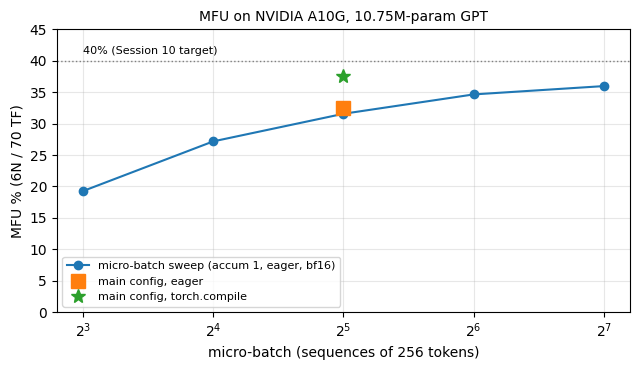

In [27]:
if DEVICE == "cuda":
    sweep_tab = MFU_TAB[MFU_TAB.config.str.startswith("D.")].copy()
    sweep_tab["mb"] = MFU["batch_sweep"]
    fig, ax = plt.subplots(figsize=(6.5, 3.8))
    ax.plot(sweep_tab.mb, sweep_tab["MFU % (6N)"], "o-", label="micro-batch sweep (accum 1, eager, bf16)")
    for prefix, mk, lab in [("B.", "s", "main config, eager"), ("E.", "*", "main config, torch.compile")]:
        rr = MFU_TAB[MFU_TAB.config.str.startswith(prefix)]
        if len(rr):
            ax.plot([MAIN["micro_batch"]], rr["MFU % (6N)"], mk, ms=10, label=lab)
    ax.axhline(40, color="grey", ls=":", lw=1); ax.text(MFU["batch_sweep"][0], 41, "40% (Session 10 target)", fontsize=8)
    ax.set_xscale("log", base=2); ax.set_xlabel("micro-batch (sequences of 256 tokens)"); ax.set_ylabel("MFU % (6N / 70 TF)")
    ax.set_ylim(0, 45); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_title(f"MFU on {gpu}, {N/1e6:.2f}M-param GPT", fontsize=10)
    fig.tight_layout(); fig.savefig("figures/mfu_batch_sweep.png", dpi=150); plt.show()

**My MFU and where the rest goes.**

- At the main config (32 x 256 x 2 = 16,384 tokens per step, bf16 autocast, eager), the loop does 351,964 tok/s. That is 6N = 64.5 MFLOP per token, so 22.7 TFLOP/s achieved, **32.4% of the A10G's 70 TF dense bf16 peak**.
  Counting attention FLOPs and dropping the `wpe` lookup gives 35.7%. Measured per step inside the real training run, with all its logging syncs, it is 345,259 tok/s.
- Had I used the A10 datasheet's 125 TF, I would have reported 18.2% for the same run.
- The GPU is never idle: kernel time per step (47.4 ms under the profiler) matches wall time (46.6 ms). Python, data loading (1%: A vs B) and launch overhead are *not* what's costing me at this batch size.
- The step splits roughly in half. GEMMs take 22.3 ms and run at about 47 TF (67% of peak). Their inner dimension is only 384, and the 65-wide `lm_head` manages 17%.
  The other ~24 ms goes to work that does no counted FLOPs: elementwise kernels (13.8 ms, including 2.5 ms of copies for the autocast casts), flash attention (4.3), LayerNorm (3.8) and fused AdamW (2.7).
  0.48 of the time x 0.67 efficiency ≈ 0.32, which is the measured MFU.
- Two levers, measured: `torch.compile` (which fuses elementwise chains and LayerNorm; I did not profile the compiled step) reaches 37.6%. A 128-sequence micro-batch reaches 36.0%. Going the other way, 8 sequences drops to 19.3%.
  So the distance to 40% here is mostly the memory-bound, non-matmul half of each step at C = 384, then small-K GEMMs. On a model this narrow I'd expect it to stay below 40% without fused kernels.
- Memory is nowhere near binding (1.31 GiB peak of 22 GiB). That is the opposite of the large-model case, where memory is the constraint that pushes MFU down.

# 6. The number 0.1, bit by bit

Question: what exactly gets stored when I write 0.1 in fp32, bf16 and fp8 E4M3?

Everything below is derived from the exact rational 1/10 with integer arithmetic (`s10lab/floats.py`); library encodings are used only afterwards, as a check.

**Step 1: 0.1 in binary.** Multiply the fractional part by 2 and take the integer part, repeatedly:

In [28]:
digits, steps_ = fl.binary_fraction_digits(Fraction(1, 10), 24)
print(" step  fraction x 2      bit")
for i, (v, d) in enumerate(steps_[:12], 1):
    print(f" {i:>4}  {str(v):>10}  -> {d}")
print("0.1 (decimal) = 0." + "".join(map(str, digits)) + "... (binary)")
check("the expansion repeats with period 4 (0011) after the first bit", "".join(map(str, digits[1:21])) == "0011" * 5)
m_norm, e_norm = fl.normalise(Fraction(1, 10))
print(f"\nnormalised: 0.1 = {m_norm} x 2^{e_norm} = 1.{''.join(map(str, fl.binary_fraction_digits(m_norm - 1, 24)[0]))}... (binary) x 2^{e_norm}")
check("0.1 = 1.6 x 2^-4", m_norm == Fraction(8, 5) and e_norm == -4)

 step  fraction x 2      bit
    1         1/5  -> 0
    2         2/5  -> 0
    3         4/5  -> 0
    4         8/5  -> 1
    5         6/5  -> 1
    6         2/5  -> 0
    7         4/5  -> 0
    8         8/5  -> 1
    9         6/5  -> 1
   10         2/5  -> 0
   11         4/5  -> 0
   12         8/5  -> 1
0.1 (decimal) = 0.000110011001100110011001... (binary)
  [ok] the expansion repeats with period 4 (0011) after the first bit

normalised: 0.1 = 8/5 x 2^-4 = 1.100110011001100110011001... (binary) x 2^-4
  [ok] 0.1 = 1.6 x 2^-4


**Step 2: encode.** Same recipe for each format: sign 0; exponent field = -4 + bias; keep the first `m` bits after the leading 1;
look at what was cut off and round to nearest (ties to even); read the value back.

In [29]:
FP16 = fl.Format("fp16", 5, 10, 15, "IEEE binary16")
FORMATS = [fl.FP32, fl.BF16, fl.E4M3]
ENC = {f.name: fl.encode(Fraction(1, 10), f) for f in FORMATS + [fl.E5M2, FP16]}
for f in FORMATS:
    r_ = ENC[f.name]
    print(f"== {f.name}  ({f.note})")
    print(f"   exponent bits {r_['exp_bits']}, bias {r_['bias']}: unbiased -4 -> biased {r_['biased_exp']} = {r_['exp_field']}")
    print(f"   mantissa: keep {r_['man_bits']} bits of .{''.join(map(str, fl.binary_fraction_digits(m_norm - 1, r_['man_bits'] + 8)[0]))}")
    print(f"             kept {r_['mantissa_kept_before_rounding']} | dropped {r_['first_dropped_bits']}... -> {r_['rounding']} -> {r_['mantissa_field']}")
    print(f"   bits {r_['bits_grouped']}   hex {r_['hex']}")
    print(f"   value (1 + {int(r_['mantissa_field'], 2)}/{2 ** r_['man_bits']}) x 2^-4 = {r_['value_exact']} = {r_['value']:.17g}")
    print(f"   error {r_['abs_error']:.3e} absolute, {r_['rel_error']:.3e} relative; spacing between neighbours here {r_['ulp_at_value']:.3e}\n")
r_ = ENC["fp16"]
print(f"(contrast) fp16, 5 exponent bits: {r_['bits_grouped']} {r_['hex']} = {r_['value']:.12g} (rel err {r_['rel_error']:.2e})")
check("fp16 hand bits match torch.float16", r_["hex"] == f"0x{int(torch.tensor(0.1).to(torch.float16).view(torch.int16)) & 0xFFFF:04X}")
r_ = ENC["fp8 E5M2"]
print(f"(contrast, not asked for) fp8 E5M2: {r_['bits_grouped']} {r_['hex']} = {r_['value']} (dropped {r_['first_dropped_bits']}... -> {r_['rounding']})")

== fp32  (IEEE 754 binary32)
   exponent bits 8, bias 127: unbiased -4 -> biased 123 = 01111011
   mantissa: keep 23 bits of .1001100110011001100110011001100
             kept 10011001100110011001100 | dropped 11001100... -> round up (remainder > 1/2 ULP) -> 10011001100110011001101
   bits 0 | 01111011 | 10011001100110011001101   hex 0x3DCCCCCD
   value (1 + 5033165/8388608) x 2^-4 = 13421773/134217728 = 0.10000000149011612
   error 1.490e-09 absolute, 1.490e-08 relative; spacing between neighbours here 7.451e-09

== bf16  (bfloat16: fp32's exponent, 7 mantissa bits)
   exponent bits 8, bias 127: unbiased -4 -> biased 123 = 01111011
   mantissa: keep 7 bits of .100110011001100
             kept 1001100 | dropped 11001100... -> round up (remainder > 1/2 ULP) -> 1001101
   bits 0 | 01111011 | 1001101   hex 0x3DCD
   value (1 + 77/128) x 2^-4 = 205/2048 = 0.10009765625
   error 9.766e-05 absolute, 9.766e-04 relative; spacing between neighbours here 4.883e-04

== fp8 E4M3 (OCP 'fn')  (OCP 

**Step 3: check the hand result against the machine.** `struct` for fp32, `torch.bfloat16` and `torch.float8_e4m3fn` (OCP E4M3, the "fn" = finite variant
with no infinities) viewed as raw integers. Plus an independent decoder, and the double-rounding question: Python's `0.1` is already a rounded
float64, so does encoding from it instead of from the exact 1/10 change anything?

In [30]:
import struct
lib = {
    "fp32": f"0x{struct.unpack('>I', struct.pack('>f', 0.1))[0]:08X}",
    "bf16": f"0x{int(torch.tensor(0.1, dtype=torch.float32).to(torch.bfloat16).view(torch.int16)) & 0xFFFF:04X}",
    "fp8 E4M3 (OCP 'fn')": f"0x{int(torch.tensor(0.1).to(torch.float8_e4m3fn).view(torch.uint8)):02X}",
    "fp8 E5M2": f"0x{int(torch.tensor(0.1).to(torch.float8_e5m2).view(torch.uint8)):02X}",
}
lib_val = {"fp32": float(torch.tensor(0.1, dtype=torch.float32)), "bf16": float(torch.tensor(0.1).to(torch.bfloat16).float()),
           "fp8 E4M3 (OCP 'fn')": float(torch.tensor(0.1).to(torch.float8_e4m3fn).float()), "fp8 E5M2": float(torch.tensor(0.1).to(torch.float8_e5m2).float())}
fmt_by = {f.name: f for f in FORMATS + [fl.E5M2]}
for k in lib:
    hand = ENC[k]
    print(f"{k:<20} hand {hand['hex']:<11} library {lib[k]:<11} value hand {hand['value']:.12g} library {lib_val[k]:.12g}")
    check(f"{k}: hand-derived bits == library bits", hand["hex"] == lib[k])
    check(f"{k}: library decodes to the hand value", hand["value"] == lib_val[k])
    check(f"{k}: independent decoder reads the bits back to the same value", fl.decode(hand["bits"], fmt_by[k]) == hand["value_exact"])
    check(f"{k}: encoding from float64(0.1) gives the same bits (no double-rounding issue)",
          fl.encode(Fraction(0.1), fmt_by[k])["bits"] == hand["bits"])
check("bf16(0.1) is fp32(0.1) rounded to its top 16 bits", ENC["bf16"]["hex"] == "0x3DCD" and lib["fp32"].startswith("0x3DCC"))

RANGES = pd.DataFrame([fl.format_range(f) for f in [fl.FP32, FP16, fl.BF16, fl.E4M3, fl.E5M2]])
print("\n", RANGES.to_string(index=False))
check("E4M3fn max finite is 448", float(torch.finfo(torch.float8_e4m3fn).max) == 448.0 == RANGES.set_index("format").loc[fl.E4M3.name, "max_finite"])
check("bf16 and fp32 share the smallest normal (same 8-bit exponent)", RANGES.min_normal[0] == RANGES.min_normal[2])

fp32                 hand 0x3DCCCCCD  library 0x3DCCCCCD  value hand 0.10000000149 library 0.10000000149
  [ok] fp32: hand-derived bits == library bits
  [ok] fp32: library decodes to the hand value
  [ok] fp32: independent decoder reads the bits back to the same value
  [ok] fp32: encoding from float64(0.1) gives the same bits (no double-rounding issue)
bf16                 hand 0x3DCD      library 0x3DCD      value hand 0.10009765625 library 0.10009765625
  [ok] bf16: hand-derived bits == library bits
  [ok] bf16: library decodes to the hand value
  [ok] bf16: independent decoder reads the bits back to the same value
  [ok] bf16: encoding from float64(0.1) gives the same bits (no double-rounding issue)
fp8 E4M3 (OCP 'fn')  hand 0x1D        library 0x1D        value hand 0.1015625 library 0.1015625
  [ok] fp8 E4M3 (OCP 'fn'): hand-derived bits == library bits
  [ok] fp8 E4M3 (OCP 'fn'): library decodes to the hand value
  [ok] fp8 E4M3 (OCP 'fn'): independent decoder reads the bits ba

### What those bits mean for training

Three small experiments: a weight update that is too small for the format, a gradient that is too small for the format, and whether this GPU can do fp8 matmuls at all.

In [31]:
w_, upd = 0.1, 1e-4
PREC_DEMO = {}
for dt in [torch.float32, torch.bfloat16]:
    wt = torch.tensor(w_, dtype=dt)
    one = bool((wt + torch.tensor(upd, dtype=dt)) == wt)
    acc = wt.clone()
    for _ in range(1000):
        acc = acc + torch.tensor(upd, dtype=dt)
    PREC_DEMO[str(dt)] = {"single_update_lost": one, "after_1000_updates": float(acc)}
    print(f"{str(dt):<15} 0.1 + 1e-4 == 0.1 ? {one!s:<5}  0.1 + 1000 x 1e-4 = {float(acc):.6f}  (exact 0.2)")
for g in [1e-2, 1e-3, 1e-4]:
    q = float(torch.tensor(g).to(torch.float8_e4m3fn).float())
    print(f"gradient {g:g} stored in E4M3: {q:.6g}")
PREC_DEMO["e4m3_1e-4"] = float(torch.tensor(1e-4).to(torch.float8_e4m3fn).float())
check("a 1e-4 update to a bf16 weight of 0.1 is lost entirely", PREC_DEMO["torch.bfloat16"]["single_update_lost"])
check("E4M3 flushes a 1e-4 gradient to zero without a scale", PREC_DEMO["e4m3_1e-4"] == 0.0)

FP8_HW = {}
if DEVICE == "cuda":
    cap = torch.cuda.get_device_capability(0)
    try:
        a8 = torch.randn(64, 64, device="cuda").to(torch.float8_e4m3fn)
        b8 = torch.randn(64, 64, device="cuda").to(torch.float8_e4m3fn).t()
        one_ = torch.tensor(1.0, device="cuda")
        torch._scaled_mm(a8, b8, scale_a=one_, scale_b=one_, out_dtype=torch.bfloat16)
        FP8_HW = {"capability": cap, "fp8_matmul": "ran"}
    except Exception as ex:
        FP8_HW = {"capability": cap, "fp8_matmul": "failed", "error": str(ex).splitlines()[0][:300]}
    print("fp8 matmul on this GPU:", FP8_HW)

torch.float32   0.1 + 1e-4 == 0.1 ? False  0.1 + 1000 x 1e-4 = 0.200002  (exact 0.2)
torch.bfloat16  0.1 + 1e-4 == 0.1 ? True   0.1 + 1000 x 1e-4 = 0.100098  (exact 0.2)
gradient 0.01 stored in E4M3: 0.00976562
gradient 0.001 stored in E4M3: 0.00195312
gradient 0.0001 stored in E4M3: 0
  [ok] a 1e-4 update to a bf16 weight of 0.1 is lost entirely
  [ok] E4M3 flushes a 1e-4 gradient to zero without a scale
fp8 matmul on this GPU: {'capability': (8, 6), 'fp8_matmul': 'failed', 'error': 'torch._scaled_mm is only supported on CUDA devices with compute capability >= 9.0 or 8.9, or ROCm MI300+'}


A short run in each precision this GPU can train in, same init, same batches, 300 steps: does bf16 change the learning curve, and what does it buy in speed?

{
 "steps": 300,
 "final_probe_loss": {
  "bf16": 1.8690963983535767,
  "fp32": 1.8667685985565186
 },
 "max_abs_probe_loss_diff": 0.03959393501281738,
 "median_tok_per_s": {
  "bf16": 343375.3075988099,
  "fp32": 175203.82148932217
 },
 "bf16_speedup": 1.9598619749269393
}


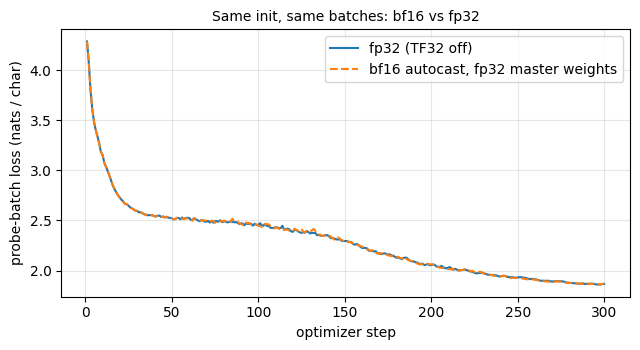

In [32]:
with section("precision_compare"):
    PREC_RUNS = {}
    for prec in ["bf16", "fp32"]:
        torch.manual_seed(SEED)
        m_ = GPT(cfg_model); m_.load_state_dict(INIT_STATE); m_ = m_.to(DEVICE).train()
        o_ = m_.configure_optimizer(MAIN["lr"], MAIN["weight_decay"], MAIN["betas"], DEVICE)
        pg = torch.Generator().manual_seed(SEED + 21)
        cfgP = dict(MAIN, max_steps=PREC["max_steps"])
        lg_, _ = train_loop(m_, o_, cfgP, lambda s: [split_chunk(D.dense_chunk("train", MAIN["micro_batch"], MAIN["T"], pg)) for _ in range(MAIN["grad_accum"])],
                            autocast_ctx(DEVICE, prec), DEVICE, probe=PROBE, val_batches=None)
        PREC_RUNS[prec] = pd.DataFrame(lg_)
        del m_, o_
pb, pf = PREC_RUNS["bf16"], PREC_RUNS["fp32"]
PREC_SUM = {"steps": PREC["max_steps"],
            "final_probe_loss": {"bf16": float(pb.probe_loss.iloc[-1]), "fp32": float(pf.probe_loss.iloc[-1])},
            "max_abs_probe_loss_diff": float((pb.probe_loss - pf.probe_loss).abs().max()),
            "median_tok_per_s": {"bf16": float(pb.tok_per_s.iloc[20:].median()), "fp32": float(pf.tok_per_s.iloc[20:].median())}}
PREC_SUM["bf16_speedup"] = PREC_SUM["median_tok_per_s"]["bf16"] / PREC_SUM["median_tok_per_s"]["fp32"]
print(json.dumps(PREC_SUM, indent=1))
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(pf.step, pf.probe_loss, label="fp32 (TF32 off)", color="C0")
ax.plot(pb.step, pb.probe_loss, label="bf16 autocast, fp32 master weights", color="C1", ls="--")
ax.set_xlabel("optimizer step"); ax.set_ylabel("probe-batch loss (nats / char)"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Same init, same batches: bf16 vs fp32", fontsize=10)
fig.tight_layout(); fig.savefig("figures/precision_bf16_vs_fp32.png", dpi=150); plt.show()
save_json("floats.json", {"derivation": {k: {kk: (str(vv) if isinstance(vv, Fraction) else vv) for kk, vv in v.items()} for k, v in ENC.items()},
                          "library": lib, "ranges": RANGES.to_dict(orient="records"), "training_demos": PREC_DEMO,
                          "fp8_hardware": FP8_HW, "precision_compare": PREC_SUM})

**The bits of 0.1**, from 0.1 = 1.1001 1001 1001..._2 x 2^-4:

| format | sign | exponent (bias) | mantissa kept | rounding | bits | hex | value | rel. error |
|---|---|---|---|---|---|---|---|---|
| fp32 | 0 | 01111011 (127) | 23 bits | up | `0 01111011 10011001100110011001101` | 0x3DCCCCCD | 0.100000001490116 | 1.5e-8 |
| bf16 | 0 | 01111011 (127) | 7 bits | up | `0 01111011 1001101` | 0x3DCD | 0.10009765625 | 9.8e-4 |
| fp8 E4M3 (OCP fn) | 0 | 0011 (7) | 3 bits | up | `0 0011 101` | 0x1D | 0.1015625 | 1.6e-2 |

In all three the dropped bits start `1100...` (0.8 ULP), so all three round up. fp16 (shown as a contrast) cuts the pattern elsewhere and rounds *down*, to 0x2E66.

**Which I'd train in, here: bf16 autocast, with fp32 master weights and fp32 AdamW state.**

- On this A10G, bf16 ran 1.96x faster than fp32 (343k vs 175k tok/s). Over 300 identical steps the two loss curves stayed within 0.04 of each other and ended at 1.869 vs 1.867.
- fp8 isn't an option on this card. `torch._scaled_mm` refuses to run on compute capability 8.6, so fp8 here would only be a storage format.
- fp16 would need loss scaling: its smallest normal number is 6.1e-5, whereas bf16 has fp32's exponent and reaches 1.2e-38.
- The one place bf16 is clearly wrong is the weights themselves. 0.1 + 1e-4 is still 0.1 in bf16, and a thousand such updates leave 0.100098 instead of 0.2. So the matmuls run in bf16, but the weights and optimiser state that accumulate small updates stay fp32.
  E4M3 is worse: it flushes a 1e-4 gradient to exactly 0 unless something scales it first.

This is a choice for this GPU and this model, not a general ranking. On Hopper or Blackwell, an fp8 recipe with scaling is the thing to try.

# Evidence summary

In [33]:
SECTION_SECONDS["notebook_total"] = round(time.time() - T_NOTEBOOK_START, 1)
chk = pd.DataFrame(CHECKS)
print(f"{len(chk)} checks, {int(chk.passed.sum())} passed, {int((~chk.passed).sum())} failed")
chk.to_csv("artifacts/checks.csv", index=False)
save_json("runtime.json", SECTION_SECONDS)
print(json.dumps(SECTION_SECONDS, indent=1))
chk[["check", "detail"]]

100 checks, 100 passed, 0 failed
{
 "data": 0.36,
 "autopsy": 1.05,
 "gradcheck": 0.47,
 "accumulation_checks": 0.89,
 "accumulation_runs": 69.42,
 "main_run": 87.81,
 "mfu_matmul": 2.16,
 "mfu_bench": 108.03,
 "precision_compare": 47.02,
 "notebook_total": 328.4
}


,check,detail
0,vocabulary is the 65 Tiny Shakespeare characters,65
1,train/val split is disjoint and complete,
2,H x D == C,6 x 64 = 384
3,context used fits the position table,"T=256, Tmax=256"
4,every parameter's actual shape equals its symbolic shape,
5,unique parameter count matches the hand formula,"10,745,088"
6,every parameter is trainable,
7,"lm_head.weight IS transformer.wte.weight (tied, one tensor)",
8,naive sum double-counts exactly the tied V*C,
9,block parameter count = 12C^2 + 2C,1770240
